# Taller WISDM — Reducción de dimensionalidad

## PCA, MDS clásico, MDS métrico, MDS no métrico y UMAP


### Sensores
- `phone-accel`
- `phone-gyro`
- `watch-accel`
- `watch-gyro`


In [62]:
import os
import random
import zipfile
import shutil
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import arff
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances, silhouette_samples, silhouette_score
import umap.umap_ as umap

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

VOLUNTARIOS = [
    i for i in range(1600, 1651)
    if i != 1614
]

random.seed(5975)
SUJETOS = random.sample(VOLUNTARIOS, 3)

print("Sujetos seleccionados aleatoriamente:")
print(sorted(SUJETOS))

SENSORES = {
    "phone-accel": ("phone", "accel"),
    "phone-gyro":  ("phone", "gyro"),
    "watch-accel": ("watch", "accel"),
    "watch-gyro":  ("watch", "gyro")
}

ZIP_EXTERNO = "/content/wisdm_dataset.zip"
CARPETA_INTERNA = "/content/WISDM_interno"
ZIP_INTERNO = "/content/WISDM_interno/wisdm-dataset.zip"
DESTINO = "/content/WISDM_seleccion"


print("✅ Librerías cargadas.")
print("Sujetos:", SUJETOS)
print("Sensores:", list(SENSORES))

Sujetos seleccionados aleatoriamente:
[1607, 1632, 1645]
✅ Librerías cargadas.
Sujetos: [1632, 1645, 1607]
Sensores: ['phone-accel', 'phone-gyro', 'watch-accel', 'watch-gyro']


In [63]:
URL_UCI = (
    "https://archive.ics.uci.edu/static/public/507/"
    "wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset.zip"
)

def zip_es_valido(ruta):
    try:
        with zipfile.ZipFile(ruta, "r") as z:
            z.testzip()
        return True
    except Exception:
        return False

if not os.path.exists(ZIP_EXTERNO) or not zip_es_valido(ZIP_EXTERNO):
    if os.path.exists(ZIP_EXTERNO):
        os.remove(ZIP_EXTERNO)

    print("Descargando dataset oficial desde UCI...")
    respuesta = requests.get(URL_UCI, stream=True, timeout=120)
    respuesta.raise_for_status()

    total = int(respuesta.headers.get("content-length", 0))
    descargados = 0

    with open(ZIP_EXTERNO, "wb") as archivo:
        for bloque in respuesta.iter_content(chunk_size=1024 * 1024):
            if bloque:
                archivo.write(bloque)
                descargados += len(bloque)

                if total:
                    porcentaje = 100 * descargados / total
                    print(
                        f"\rDescargado: {porcentaje:6.2f}%",
                        end=""
                    )

    print("\n✅ Descarga terminada.")
else:
    print("✅ Ya existe un ZIP válido. Se reutilizará.")

tamano_mb = os.path.getsize(ZIP_EXTERNO) / (1024**2)

print(f"Tamaño del ZIP: {tamano_mb:.2f} MB")

if not zip_es_valido(ZIP_EXTERNO):
    raise RuntimeError(
        "El ZIP no pudo validarse. Ejecuta nuevamente esta celda."
    )

print("✅ ZIP válido y completo.")

✅ Ya existe un ZIP válido. Se reutilizará.
Tamaño del ZIP: 295.92 MB
✅ ZIP válido y completo.


In [64]:
os.makedirs(CARPETA_INTERNA, exist_ok=True)
os.makedirs(DESTINO, exist_ok=True)

if not os.path.exists(ZIP_INTERNO):

    with zipfile.ZipFile(ZIP_EXTERNO, "r") as z:

        nombres = z.namelist()

        internos = [
            nombre for nombre in nombres
            if nombre.lower().endswith("wisdm-dataset.zip")
        ]

        if not internos:
            raise FileNotFoundError(
                "No se encontró wisdm-dataset.zip dentro del ZIP externo."
            )

        z.extract(internos[0], CARPETA_INTERNA)

        ruta_extraida = os.path.join(
            CARPETA_INTERNA,
            internos[0]
        )

        if ruta_extraida != ZIP_INTERNO:
            os.makedirs(os.path.dirname(ZIP_INTERNO), exist_ok=True)
            os.replace(ruta_extraida, ZIP_INTERNO)

print("ZIP interno:", ZIP_INTERNO)

archivos_necesarios = []

for sujeto in SUJETOS:
    for sensor, (dispositivo, tipo) in SENSORES.items():
        archivos_necesarios.append(
            f"data_{sujeto}_{tipo}_{dispositivo}.arff"
        )

with zipfile.ZipFile(ZIP_INTERNO, "r") as z:

    nombres_zip = z.namelist()

    print("\nExtrayendo archivos necesarios...\n")

    for nombre in archivos_necesarios:

        coincidencias = [
            archivo for archivo in nombres_zip
            if archivo.endswith("/" + nombre) or archivo == nombre
        ]

        if not coincidencias:
            raise FileNotFoundError(
                f"No se encontró en el ZIP interno: {nombre}"
            )

        z.extract(coincidencias[0], DESTINO)

        print("✅", nombre)

print(f"\n✅ Total extraído: {len(archivos_necesarios)} archivos.")

ZIP interno: /content/WISDM_interno/wisdm-dataset.zip

Extrayendo archivos necesarios...

✅ data_1632_accel_phone.arff
✅ data_1632_gyro_phone.arff
✅ data_1632_accel_watch.arff
✅ data_1632_gyro_watch.arff
✅ data_1645_accel_phone.arff
✅ data_1645_gyro_phone.arff
✅ data_1645_accel_watch.arff
✅ data_1645_gyro_watch.arff
✅ data_1607_accel_phone.arff
✅ data_1607_gyro_phone.arff
✅ data_1607_accel_watch.arff
✅ data_1607_gyro_watch.arff

✅ Total extraído: 12 archivos.


In [65]:
RUTAS = {}

for sujeto in SUJETOS:

    RUTAS[sujeto] = {}

    for sensor, (dispositivo, tipo) in SENSORES.items():

        nombre = f"data_{sujeto}_{tipo}_{dispositivo}.arff"

        encontrados = []

        for raiz, _, archivos in os.walk(DESTINO):
            if nombre in archivos:
                encontrados.append(
                    os.path.join(raiz, nombre)
                )

        if not encontrados:
            raise FileNotFoundError(
                f"No se encontró el archivo {nombre}"
            )

        RUTAS[sujeto][sensor] = encontrados[0]

print("RUTAS CONFIRMADAS\n")

for sujeto in SUJETOS:
    for sensor in SENSORES:
        print(
            f"{sujeto} | {sensor:12} | "
            f"{RUTAS[sujeto][sensor]}"
        )

print("\n✅ Las 12 rutas están disponibles.")

RUTAS CONFIRMADAS

1632 | phone-accel  | /content/WISDM_seleccion/wisdm-dataset/arff_files/phone/accel/data_1632_accel_phone.arff
1632 | phone-gyro   | /content/WISDM_seleccion/wisdm-dataset/arff_files/phone/gyro/data_1632_gyro_phone.arff
1632 | watch-accel  | /content/WISDM_seleccion/wisdm-dataset/arff_files/watch/accel/data_1632_accel_watch.arff
1632 | watch-gyro   | /content/WISDM_seleccion/wisdm-dataset/arff_files/watch/gyro/data_1632_gyro_watch.arff
1645 | phone-accel  | /content/WISDM_seleccion/wisdm-dataset/arff_files/phone/accel/data_1645_accel_phone.arff
1645 | phone-gyro   | /content/WISDM_seleccion/wisdm-dataset/arff_files/phone/gyro/data_1645_gyro_phone.arff
1645 | watch-accel  | /content/WISDM_seleccion/wisdm-dataset/arff_files/watch/accel/data_1645_accel_watch.arff
1645 | watch-gyro   | /content/WISDM_seleccion/wisdm-dataset/arff_files/watch/gyro/data_1645_gyro_watch.arff
1607 | phone-accel  | /content/WISDM_seleccion/wisdm-dataset/arff_files/phone/accel/data_1607_accel_p

Construcción de las matrices


In [66]:
FEATURES = (
    [f'"X{i}"' for i in range(10)] +
    [f'"Y{i}"' for i in range(10)] +
    [f'"Z{i}"' for i in range(10)]
)

LABEL = '"ACTIVITY"'

def leer_arff(ruta):

    datos, meta = arff.loadarff(ruta)

    df = pd.DataFrame(datos)


    for columna in df.columns:

        if df[columna].dtype == object:

            df[columna] = df[columna].apply(
                lambda x:
                    x.decode("utf-8")
                    if isinstance(x, bytes)
                    else x
            )

    return df


def construir_matriz(ruta):

    df = leer_arff(ruta)

    faltantes = [
        columna
        for columna in FEATURES + [LABEL]
        if columna not in df.columns
    ]

    if faltantes:
        raise ValueError(
            f"Faltan columnas: {faltantes}"
        )

    X = df[FEATURES].astype(float).to_numpy()
    y = df[LABEL].astype(str).to_numpy()

    return X, y, df


DATOS = {}

for sujeto in SUJETOS:

    DATOS[sujeto] = {}

    for sensor in SENSORES:

        X, y, df = construir_matriz(
            RUTAS[sujeto][sensor]
        )

        DATOS[sujeto][sensor] = {
            "X": X,
            "y": y,
            "df": df
        }

        print(
            f"{sujeto} | {sensor:12} | "
            f"matriz = {X.shape} | "
            f"actividades = {len(np.unique(y))}"
        )

print("\n✅ Los 12 conjuntos fueron cargados.")

1632 | phone-accel  | matriz = (321, 30) | actividades = 18
1632 | phone-gyro   | matriz = (321, 30) | actividades = 18
1632 | watch-accel  | matriz = (324, 30) | actividades = 18
1632 | watch-gyro   | matriz = (324, 30) | actividades = 18
1645 | phone-accel  | matriz = (803, 30) | actividades = 18
1645 | phone-gyro   | matriz = (401, 30) | actividades = 18
1645 | watch-accel  | matriz = (338, 30) | actividades = 18
1645 | watch-gyro   | matriz = (338, 30) | actividades = 18
1607 | phone-accel  | matriz = (383, 30) | actividades = 17
1607 | phone-gyro   | matriz = (383, 30) | actividades = 17
1607 | watch-accel  | matriz = (329, 30) | actividades = 18
1607 | watch-gyro   | matriz = (329, 30) | actividades = 18

✅ Los 12 conjuntos fueron cargados.


In [67]:
print("CARACTERÍSTICAS UTILIZADAS:")
print(FEATURES)

print("\nDIMENSIONES:")
for sujeto in SUJETOS:
    for sensor in SENSORES:
        X = DATOS[sujeto][sensor]["X"]
        print(f"{sujeto} | {sensor:12} | {X.shape}")

print("\nACTIVIDADES:")
for sujeto in SUJETOS:
    for sensor in SENSORES:
        y = DATOS[sujeto][sensor]["y"]
        print(
            f"{sujeto} | {sensor:12} | "
            f"{sorted(np.unique(y))}"
        )

print("\n✅ Verificación terminada.")

CARACTERÍSTICAS UTILIZADAS:
['"X0"', '"X1"', '"X2"', '"X3"', '"X4"', '"X5"', '"X6"', '"X7"', '"X8"', '"X9"', '"Y0"', '"Y1"', '"Y2"', '"Y3"', '"Y4"', '"Y5"', '"Y6"', '"Y7"', '"Y8"', '"Y9"', '"Z0"', '"Z1"', '"Z2"', '"Z3"', '"Z4"', '"Z5"', '"Z6"', '"Z7"', '"Z8"', '"Z9"']

DIMENSIONES:
1632 | phone-accel  | (321, 30)
1632 | phone-gyro   | (321, 30)
1632 | watch-accel  | (324, 30)
1632 | watch-gyro   | (324, 30)
1645 | phone-accel  | (803, 30)
1645 | phone-gyro   | (401, 30)
1645 | watch-accel  | (338, 30)
1645 | watch-gyro   | (338, 30)
1607 | phone-accel  | (383, 30)
1607 | phone-gyro   | (383, 30)
1607 | watch-accel  | (329, 30)
1607 | watch-gyro   | (329, 30)

ACTIVIDADES:
1632 | phone-accel  | ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
1632 | phone-gyro   | ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']
1632 | watch-accel  | ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 

Métodos de reducción de dimensionalidad

Se utilizarán los cinco métodos solicitados:

1. **PCA**
2. **MDS clásico**
3. **MDS métrico**
4. **MDS no métrico**
5. **UMAP**


In [68]:
def estandarizar(X):

    media = X.mean(axis=0)
    desviacion = X.std(axis=0)

    desviacion[desviacion == 0] = 1

    return (X - media) / desviacion


def seleccionar_para_mds(X, y):
    indices = np.arange(len(X))
    return X, y, indices


def mds_clasico(X):

    D = pairwise_distances(
        X,
        metric="euclidean"
    )

    n = len(D)

    J = (
        np.eye(n)
        - np.ones((n, n)) / n
    )

    B = -0.5 * J @ (D ** 2) @ J

    valores, vectores = np.linalg.eigh(B)

    orden = np.argsort(valores)[::-1]

    valores = valores[orden]
    vectores = vectores[:, orden]


    valores_2d = np.maximum(
        valores[:2],
        0
    )

    coordenadas = (
        vectores[:, :2]
        * np.sqrt(valores_2d)
    )

    return coordenadas


def ejecutar_metodos(X, y):

    Xs = estandarizar(X)

    resultados = {}
    etiquetas = {}


    pca = PCA(
        n_components=2,
        random_state=RANDOM_STATE
    )

    resultados["PCA"] = pca.fit_transform(Xs)
    etiquetas["PCA"] = y


    Xm, ym, indices = seleccionar_para_mds(
        Xs,
        y
    )


    resultados["MDS clásico"] = mds_clasico(Xm)
    etiquetas["MDS clásico"] = ym


    mds_metric = MDS(
        n_components=2,
        metric=True,
        random_state=RANDOM_STATE,
        n_init=1,
        max_iter=250
    )

    resultados["MDS métrico"] = (
        mds_metric.fit_transform(Xm)
    )

    etiquetas["MDS métrico"] = ym


    mds_nonmetric = MDS(
        n_components=2,
        metric=False,
        random_state=RANDOM_STATE,
        n_init=1,
        max_iter=250
    )

    resultados["MDS no métrico"] = (
        mds_nonmetric.fit_transform(Xm)
    )

    etiquetas["MDS no métrico"] = ym


    n_neighbors = min(
        15,
        max(2, len(Xs) - 1)
    )

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        metric="euclidean",
        random_state=RANDOM_STATE
    )

    resultados["UMAP"] = (
        reducer.fit_transform(Xs)
    )

    etiquetas["UMAP"] = y


    return resultados, etiquetas


print("✅ Funciones de PCA, MDS y UMAP definidas.")

✅ Funciones de PCA, MDS y UMAP definidas.


In [69]:
def graficar_resultado(
    coordenadas,
    etiquetas,
    titulo
):

    plt.figure(figsize=(8, 6))

    actividades = sorted(
        np.unique(etiquetas)
    )

    for actividad in actividades:

        mascara = (
            etiquetas == actividad
        )

        plt.scatter(
            coordenadas[mascara, 0],
            coordenadas[mascara, 1],
            label=actividad,
            alpha=0.65,
            s=25
        )

    plt.title(titulo)

    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")

    plt.legend(
        title="ACTIVITY",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


print("✅ Función de visualización definida.")

✅ Función de visualización definida.


Resultados individuales





SUJETO 1632 | SENSOR phone-accel


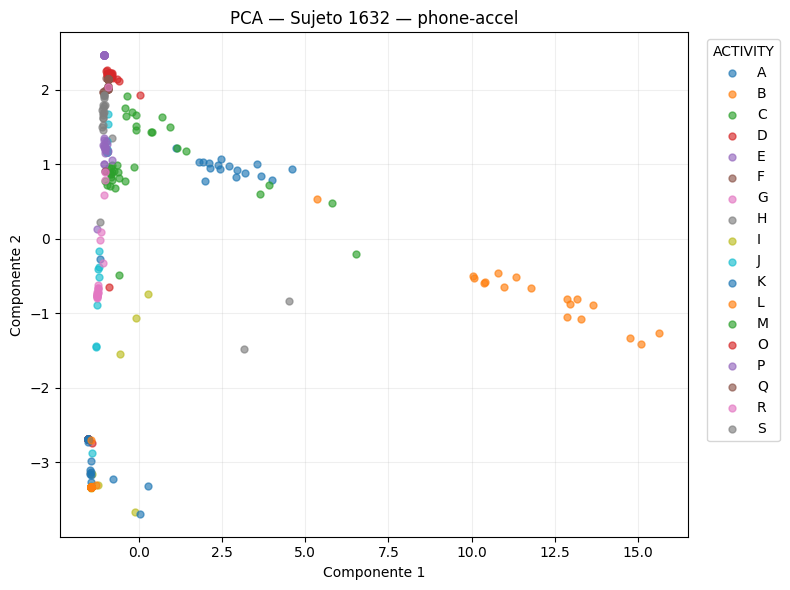

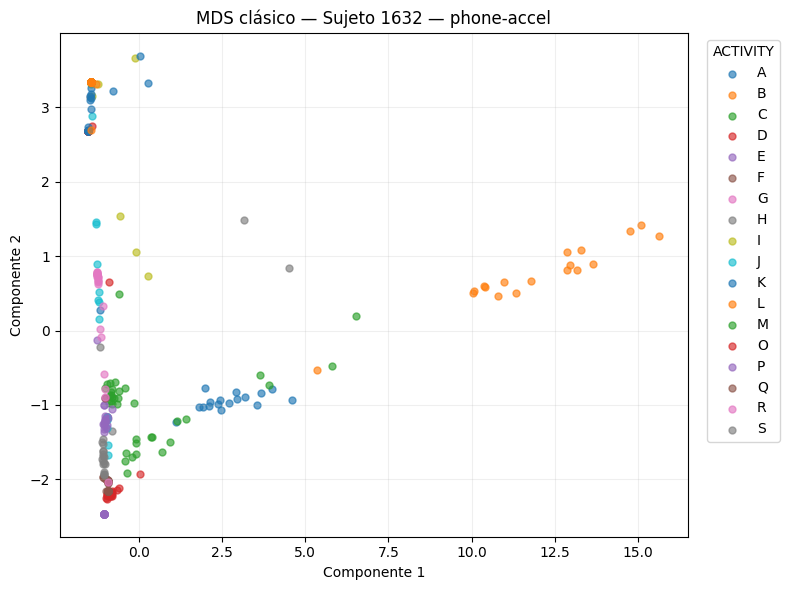

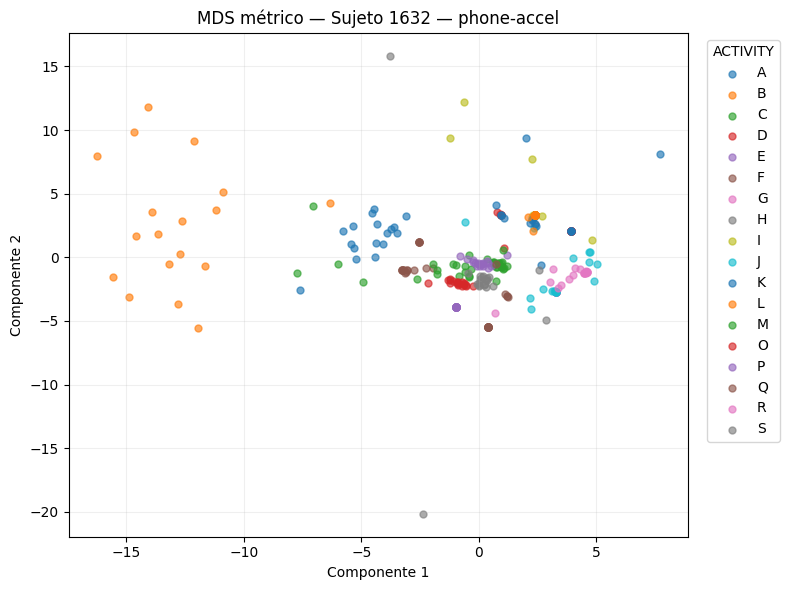

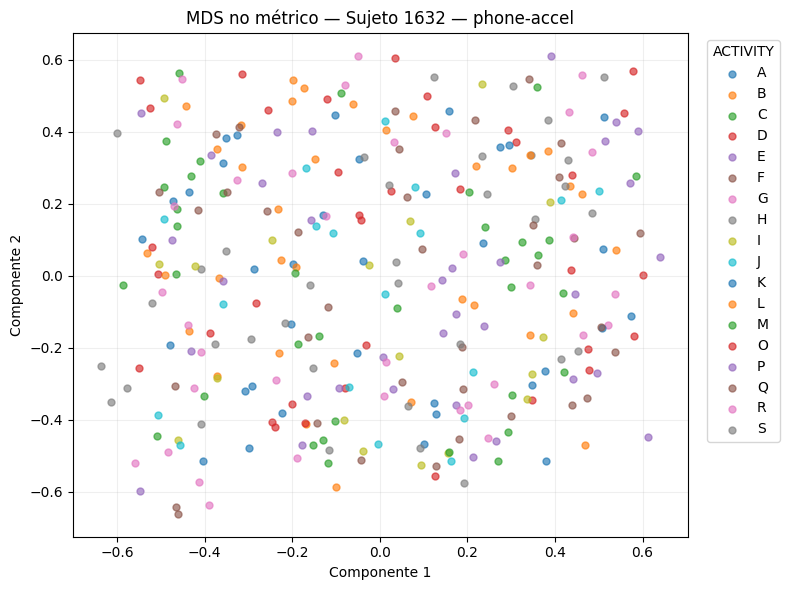

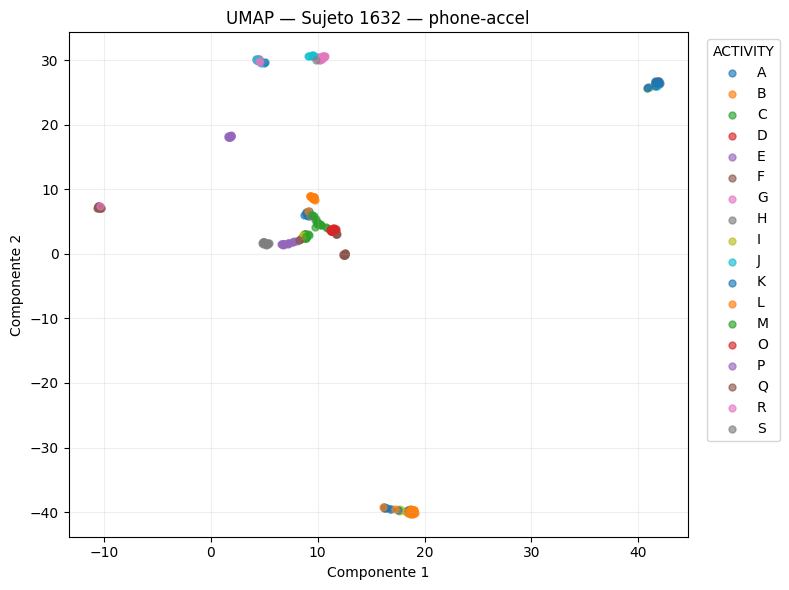


SUJETO 1632 | SENSOR phone-gyro


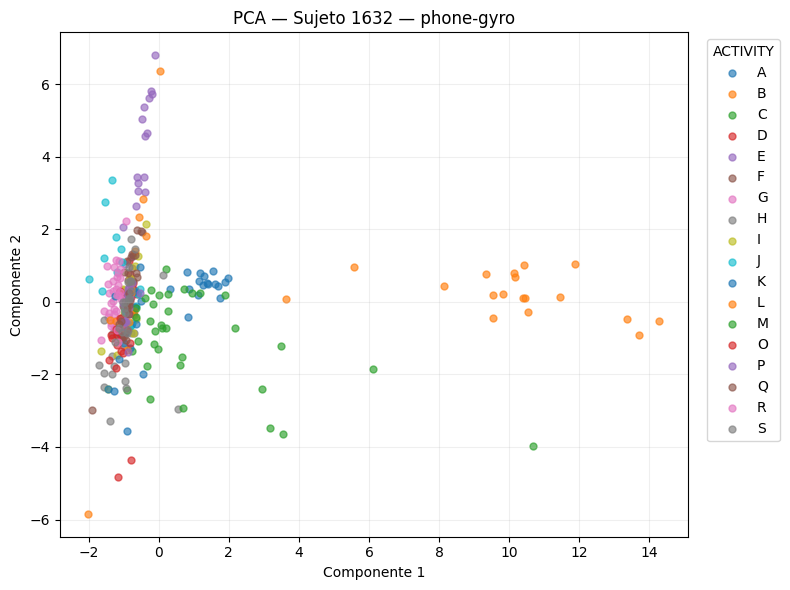

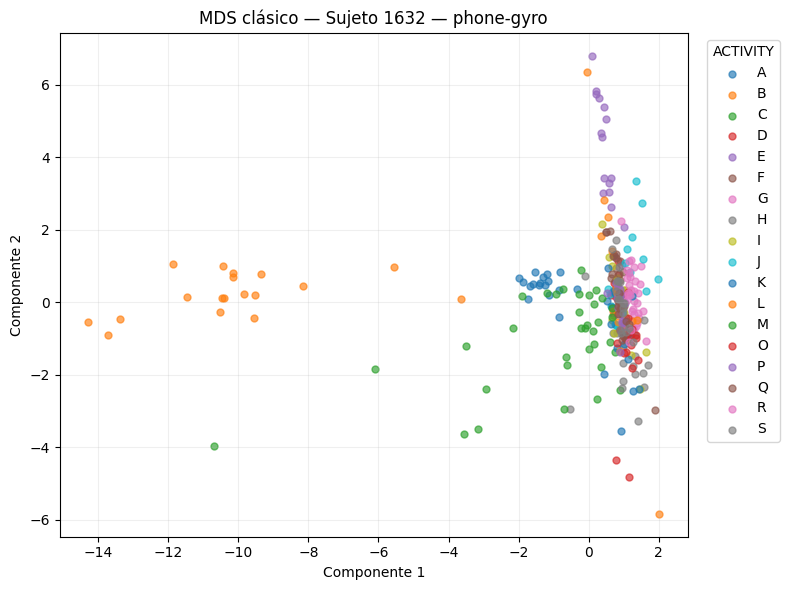

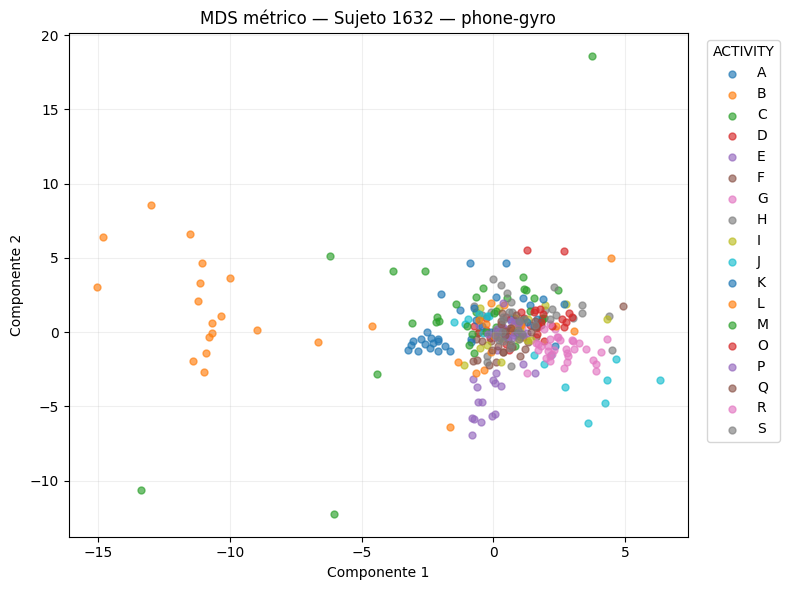

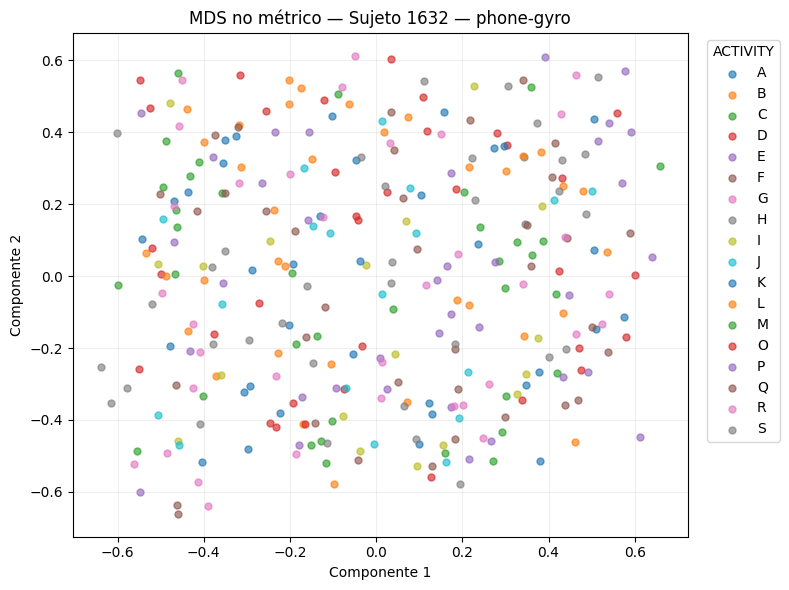

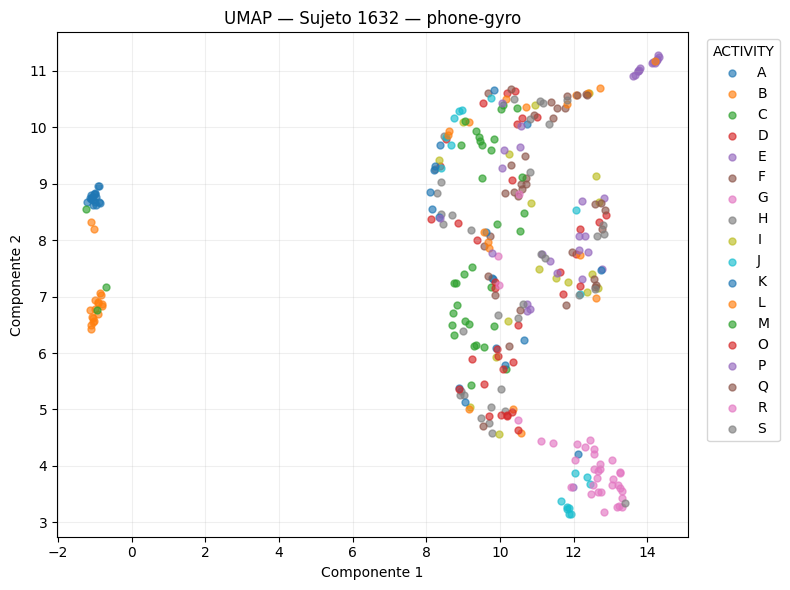


SUJETO 1632 | SENSOR watch-accel


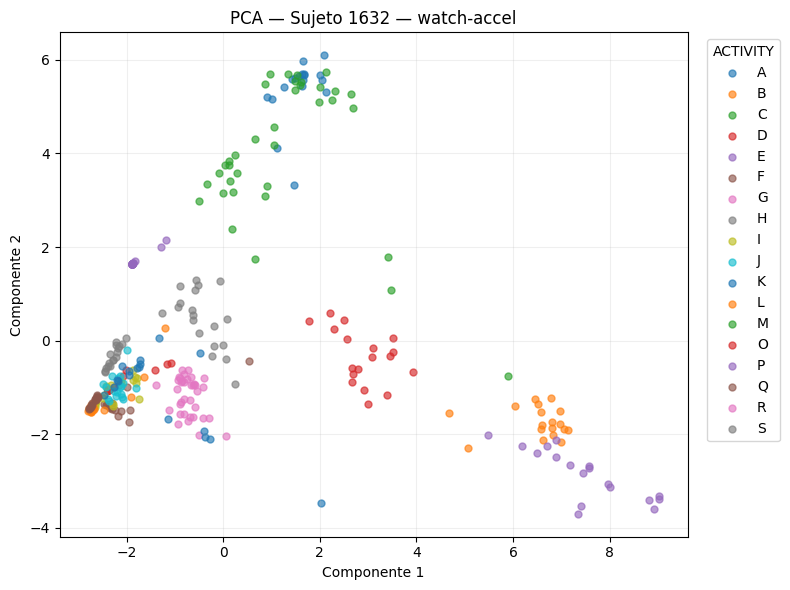

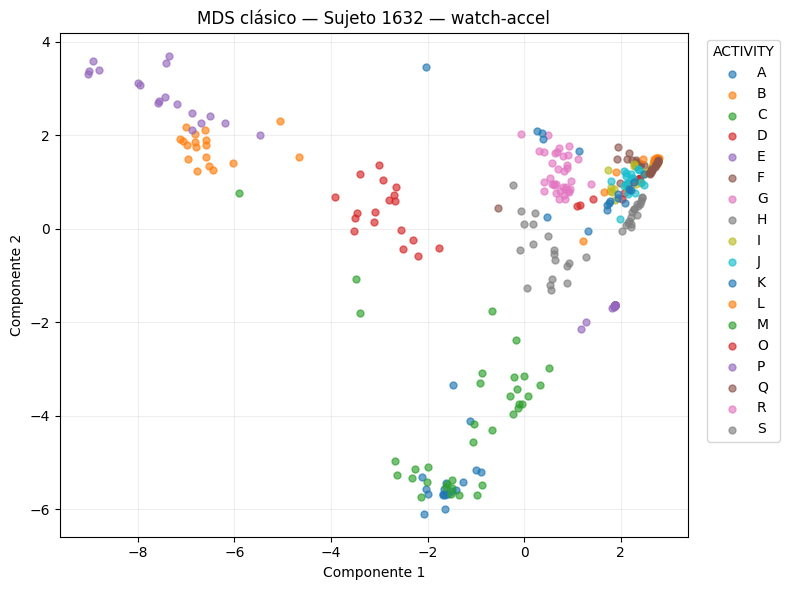

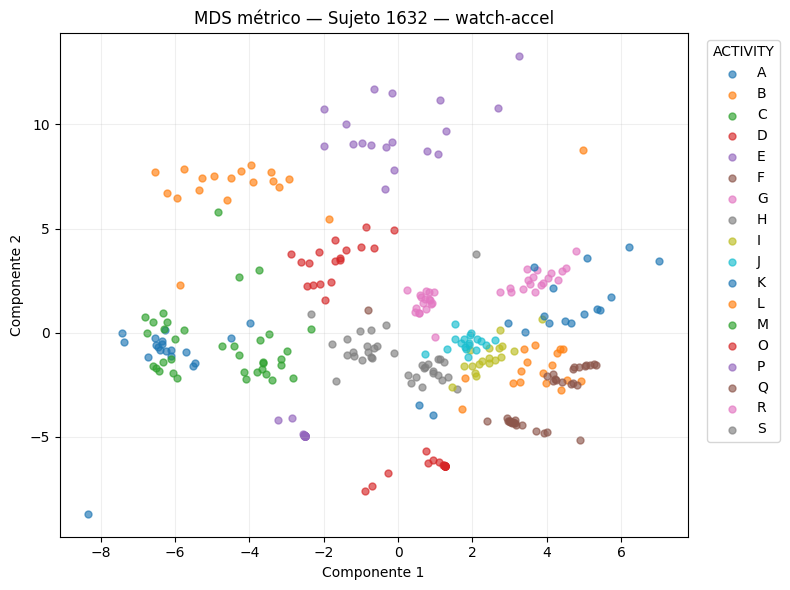

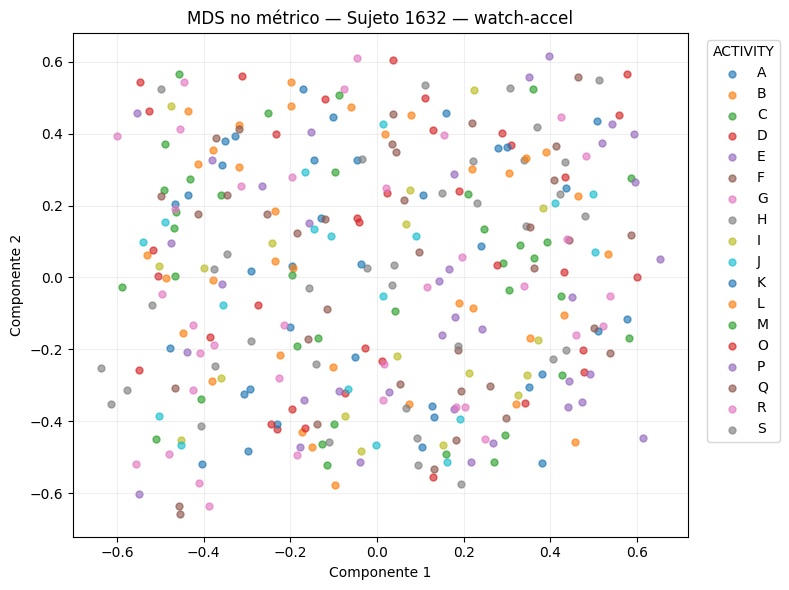

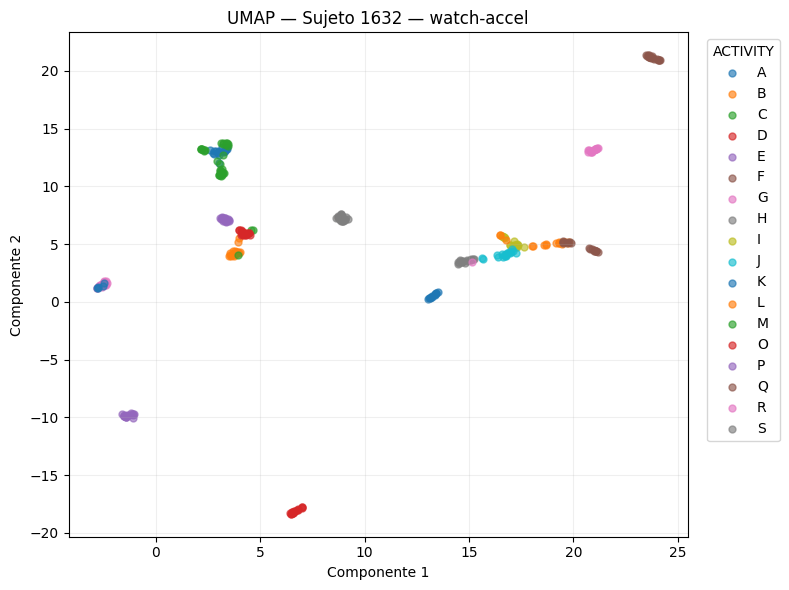


SUJETO 1632 | SENSOR watch-gyro


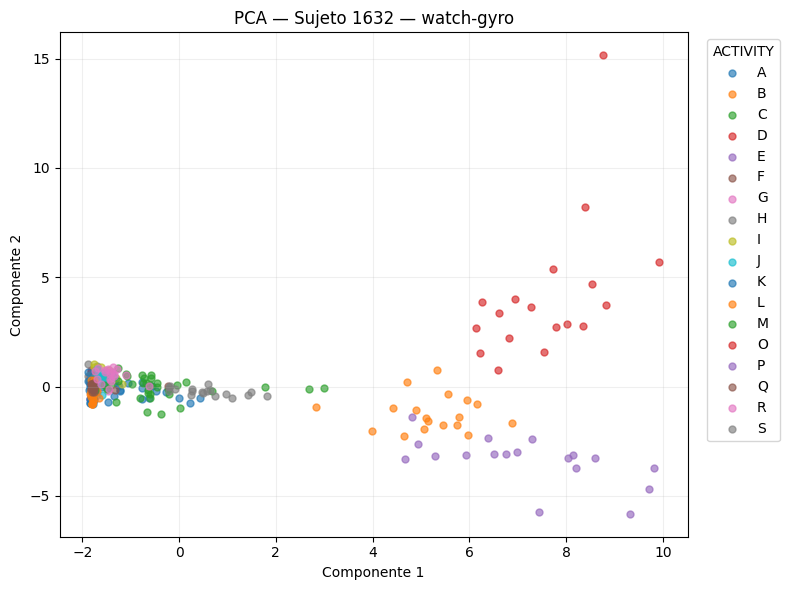

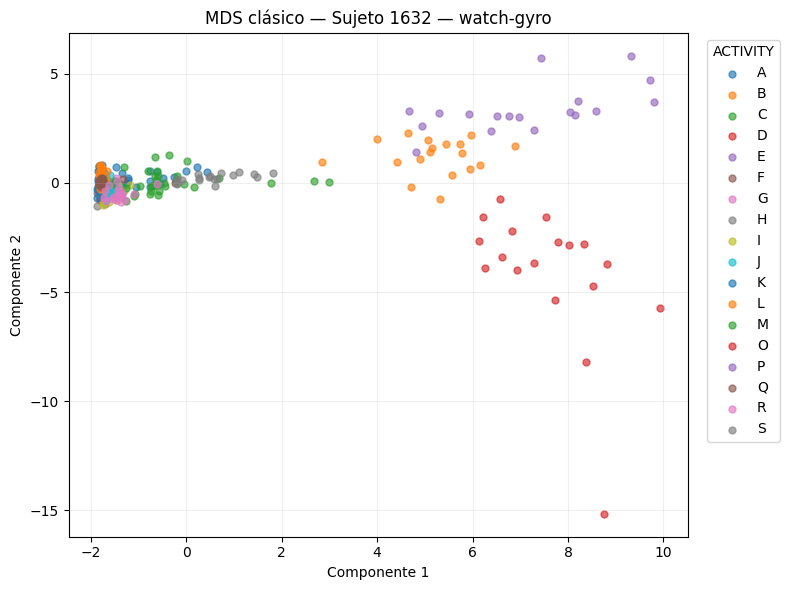

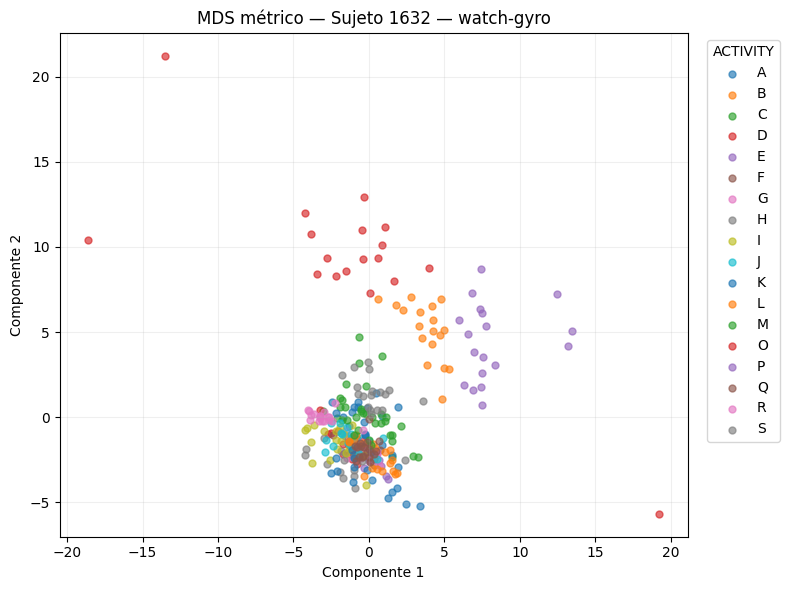

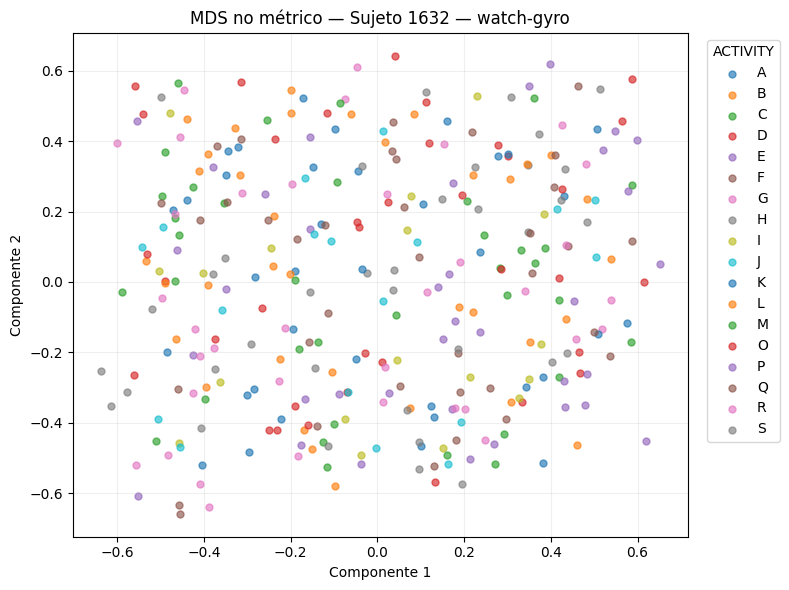

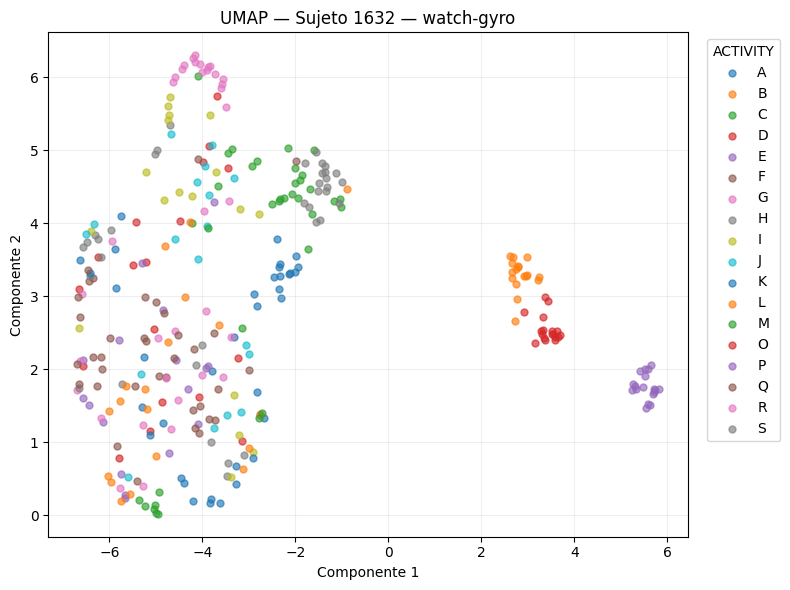


SUJETO 1645 | SENSOR phone-accel


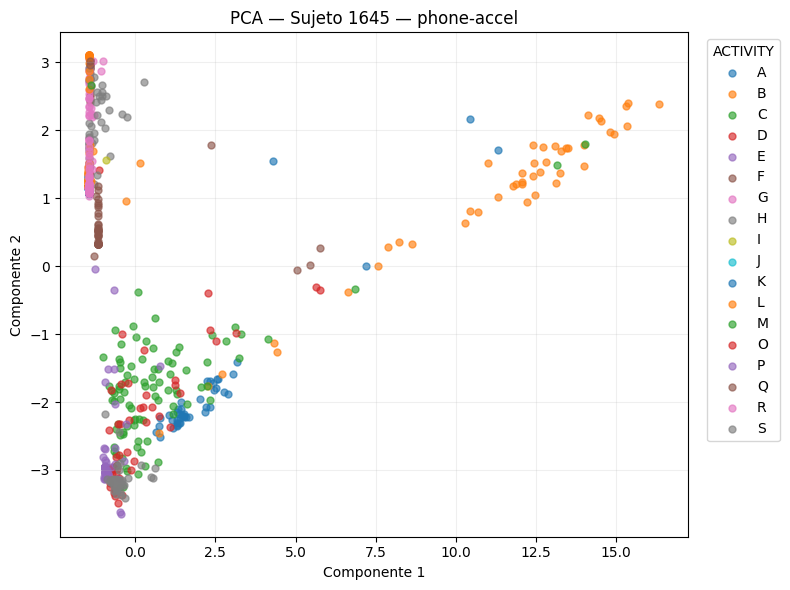

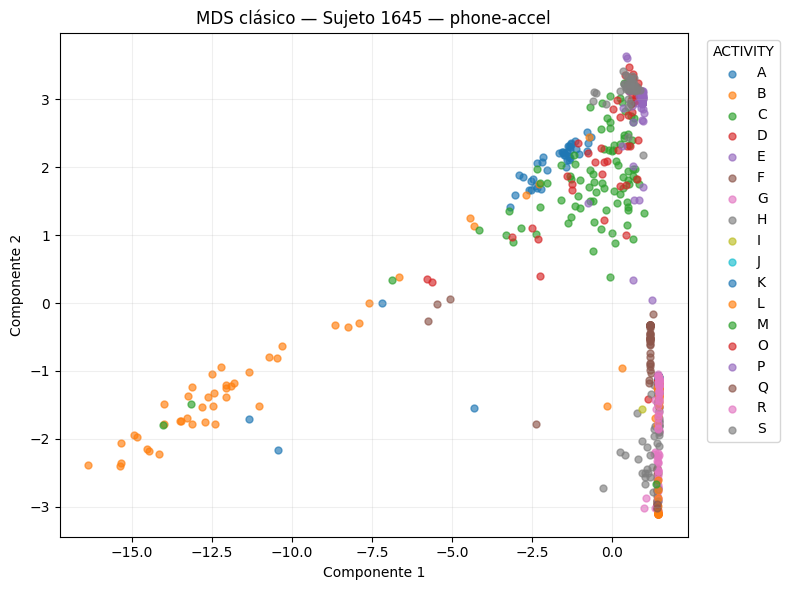

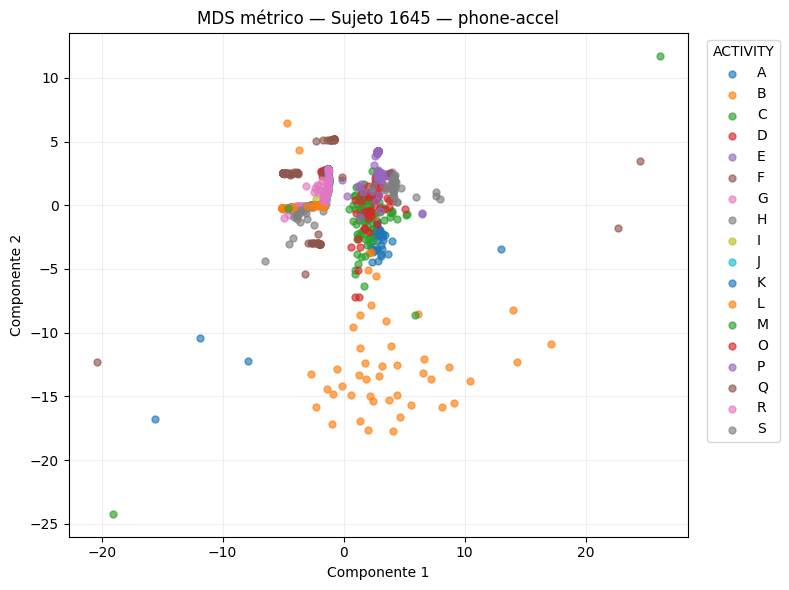

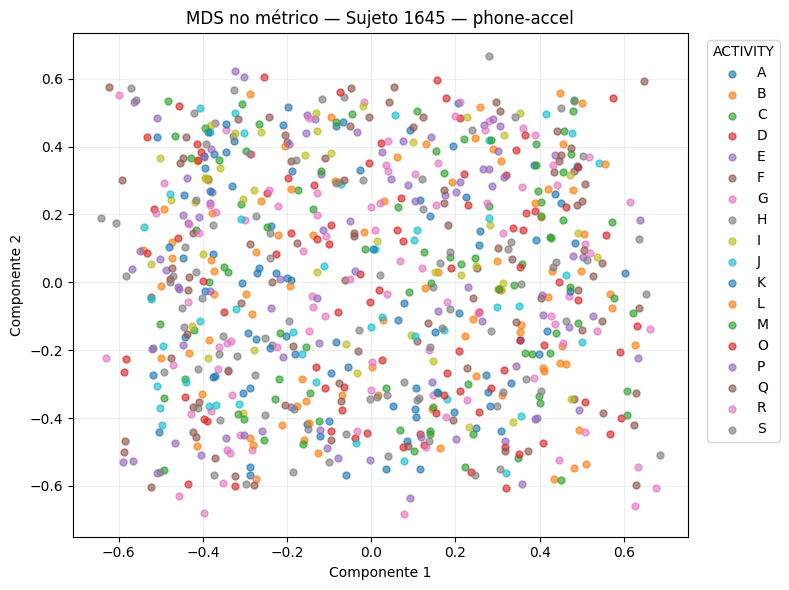

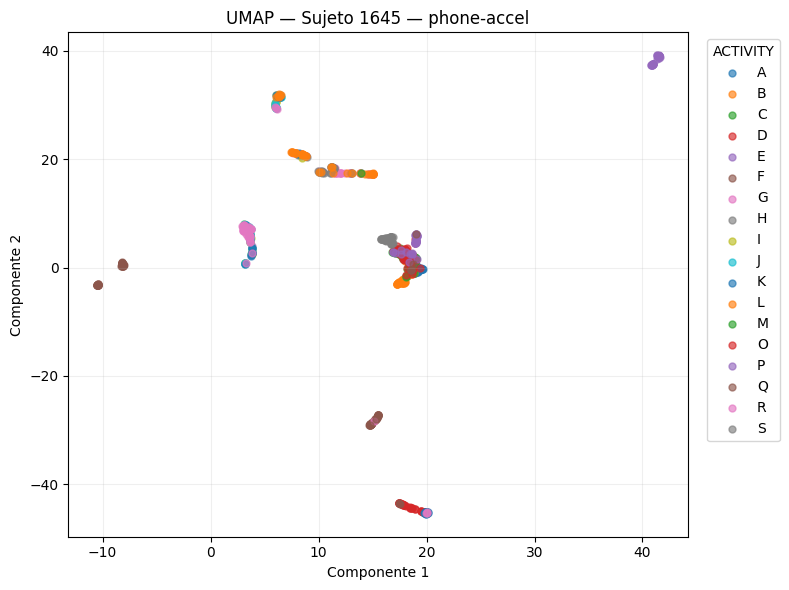


SUJETO 1645 | SENSOR phone-gyro


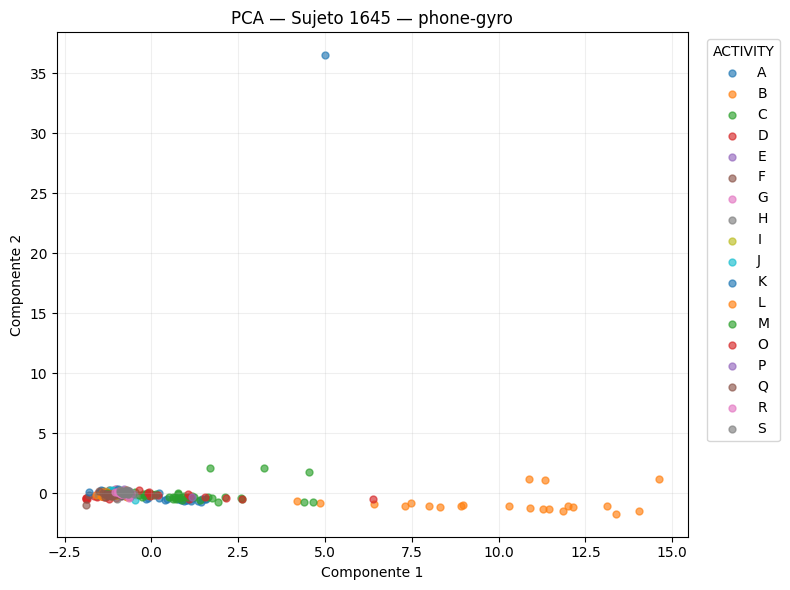

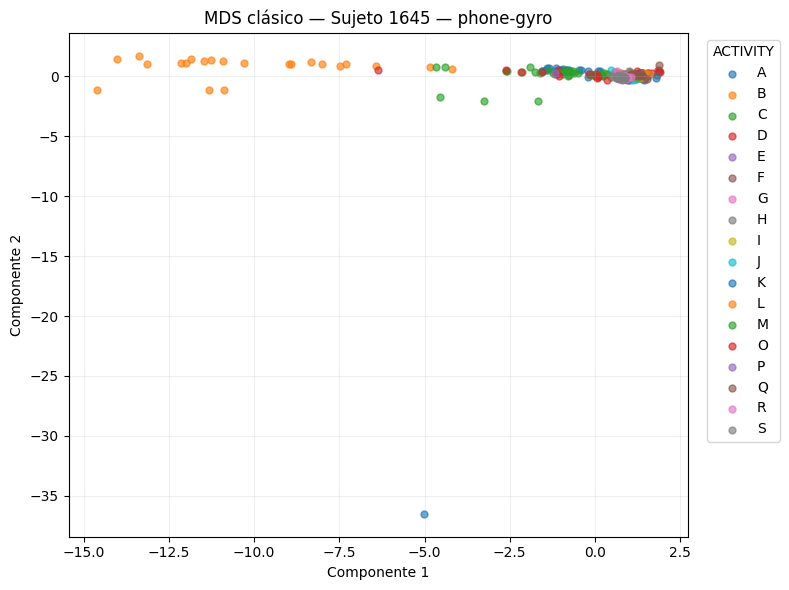

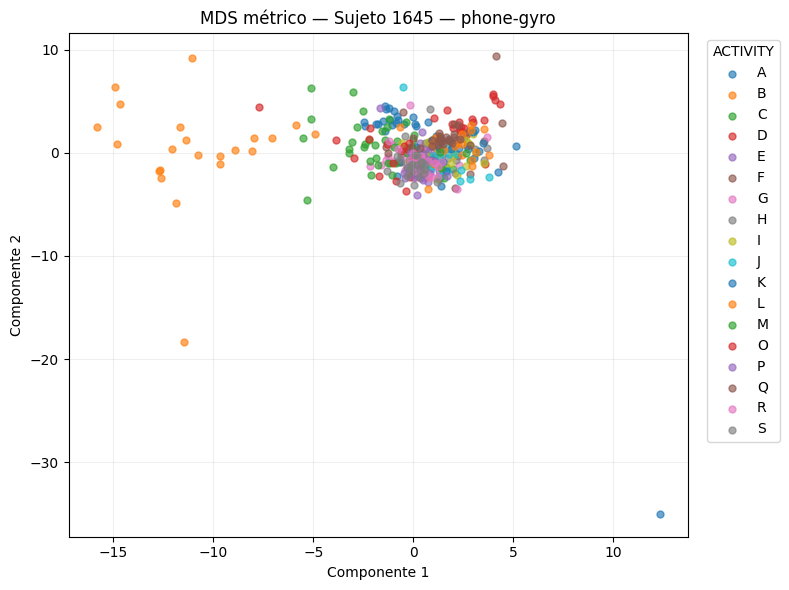

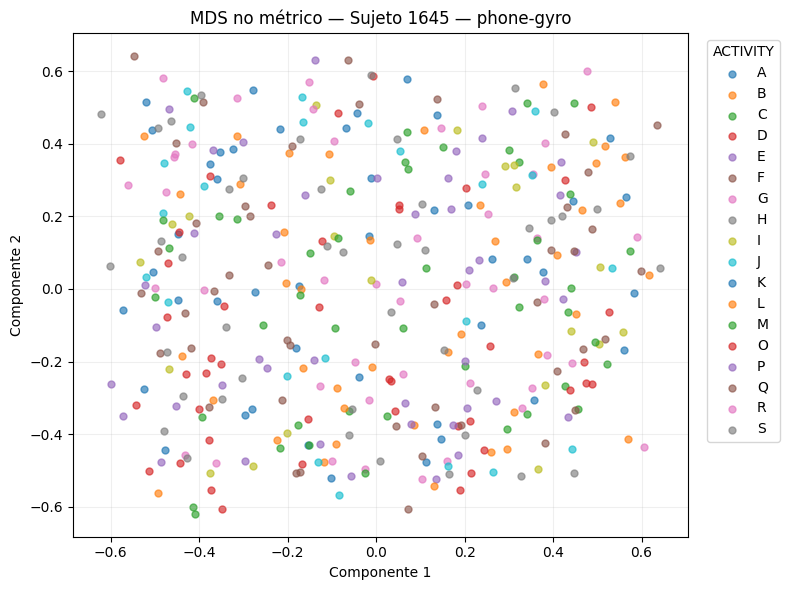

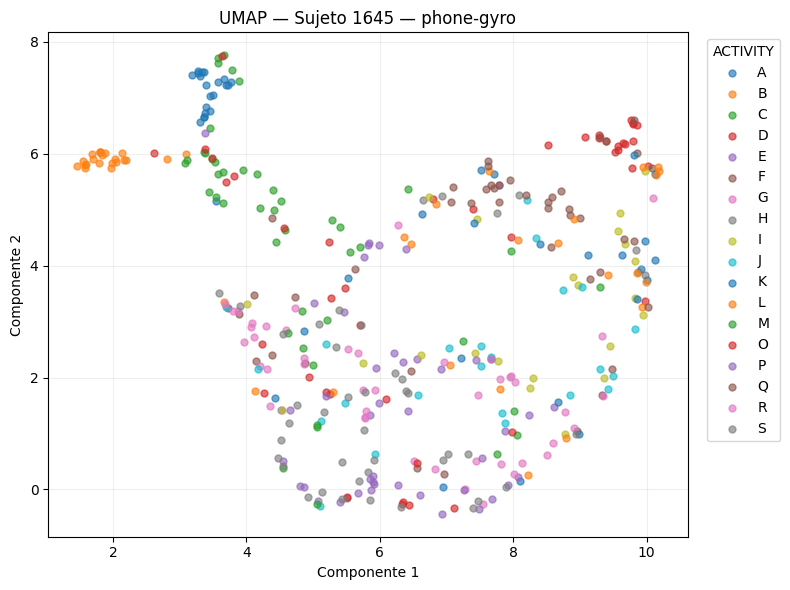


SUJETO 1645 | SENSOR watch-accel


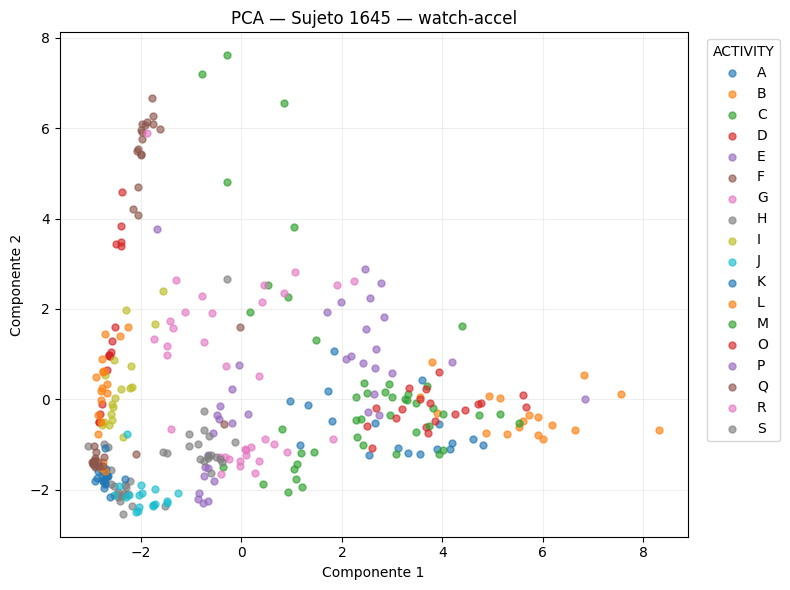

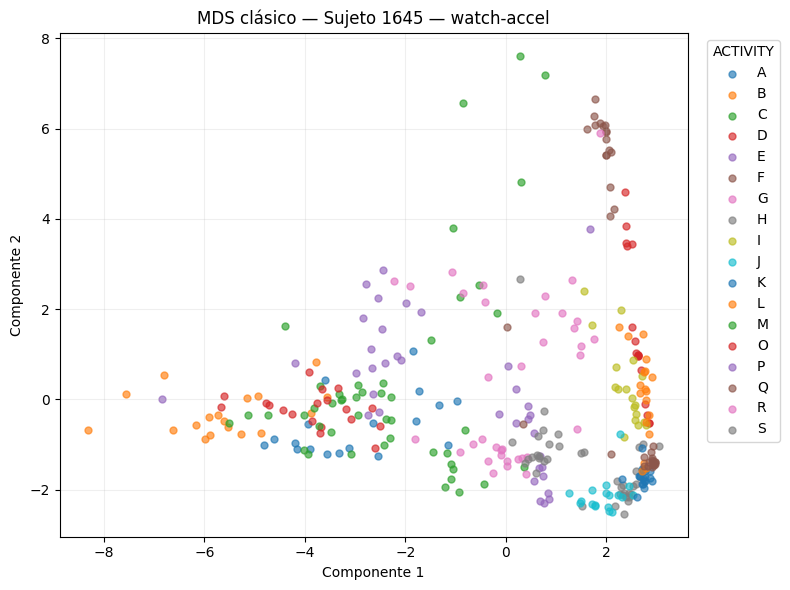

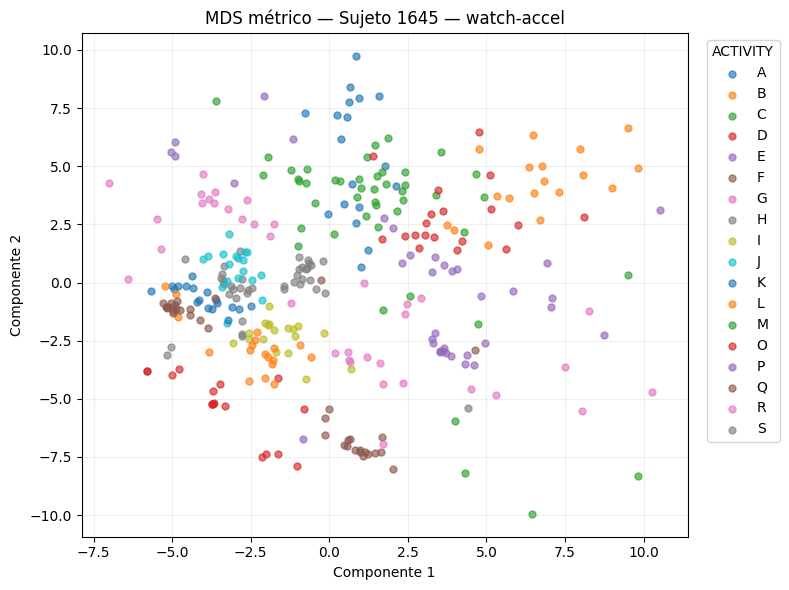

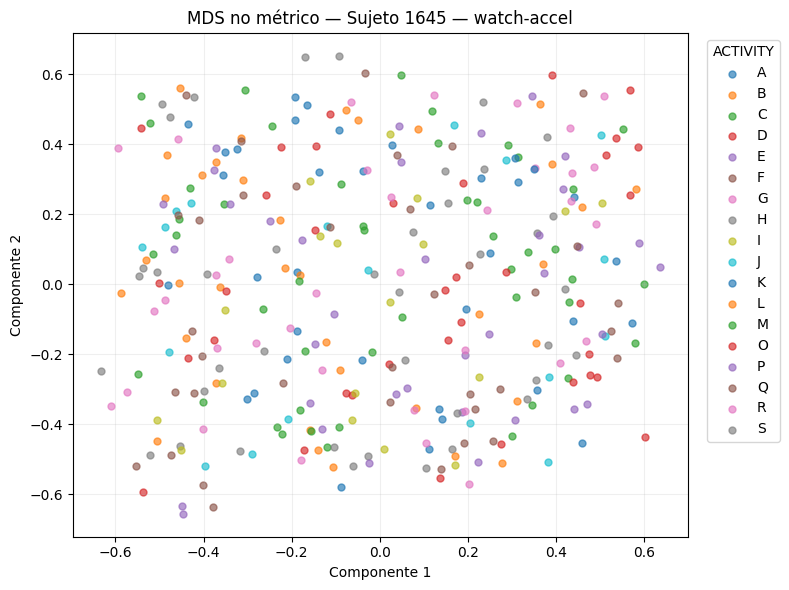

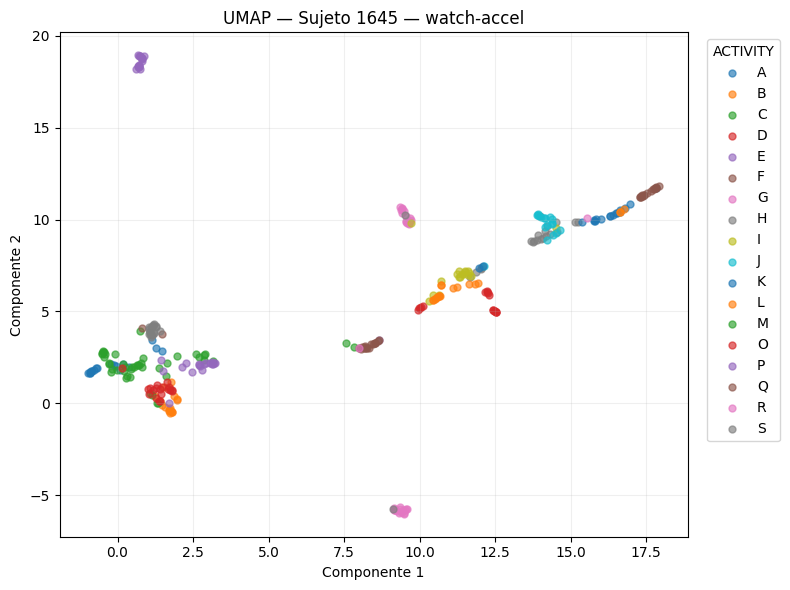


SUJETO 1645 | SENSOR watch-gyro


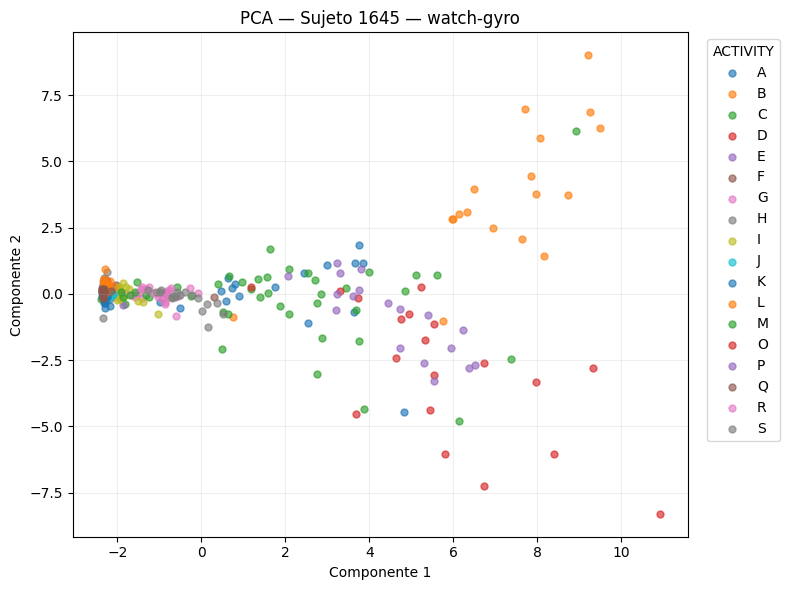

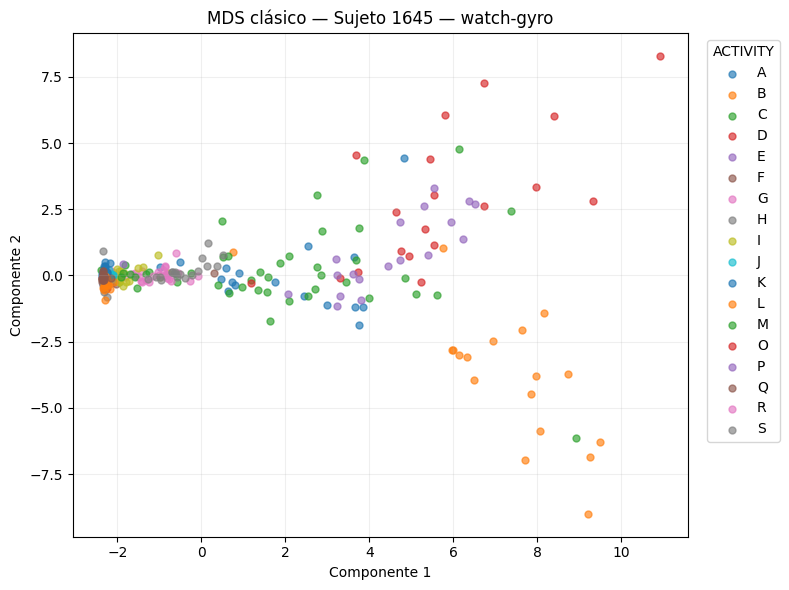

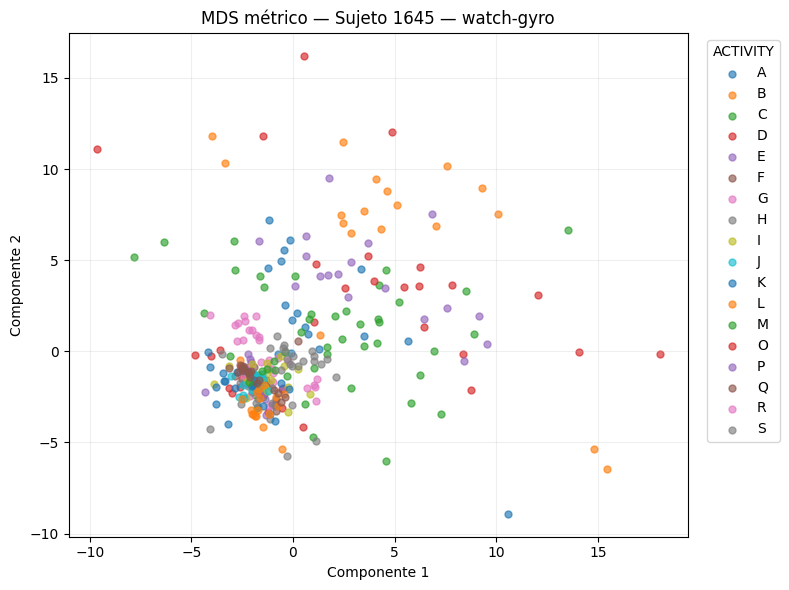

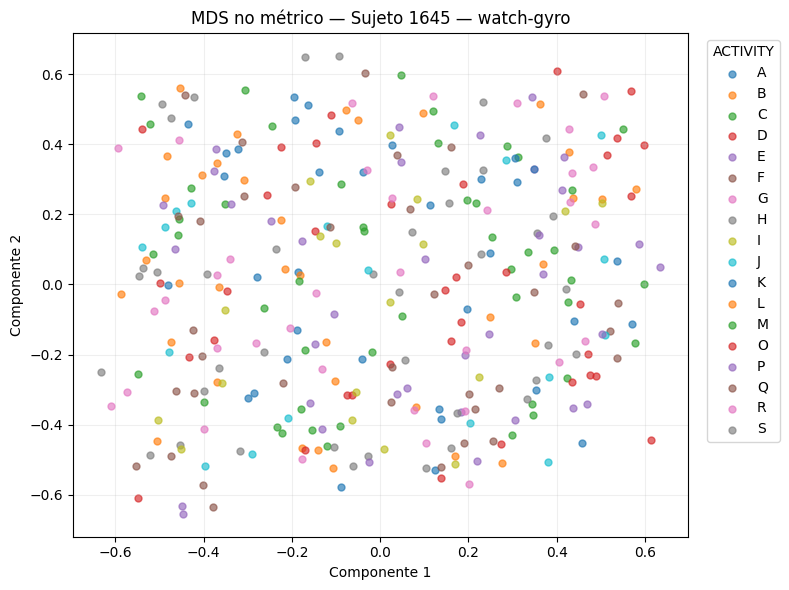

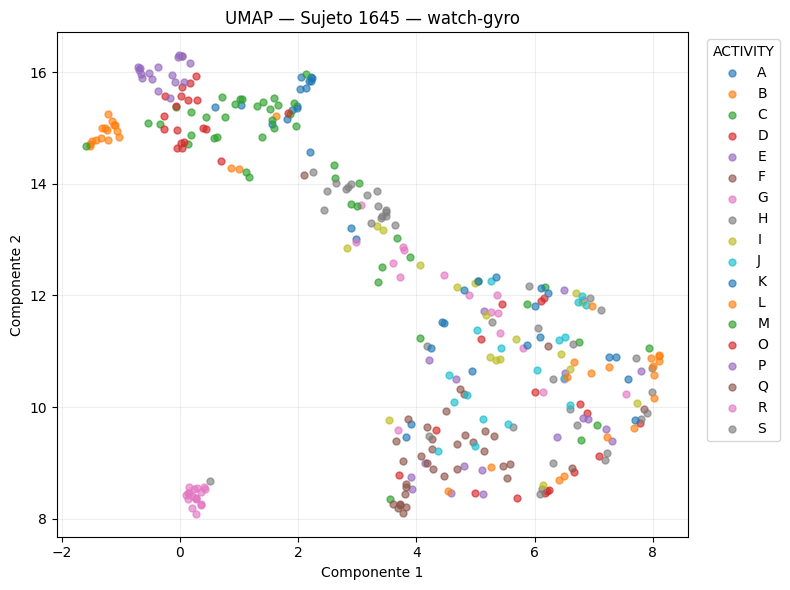


SUJETO 1607 | SENSOR phone-accel


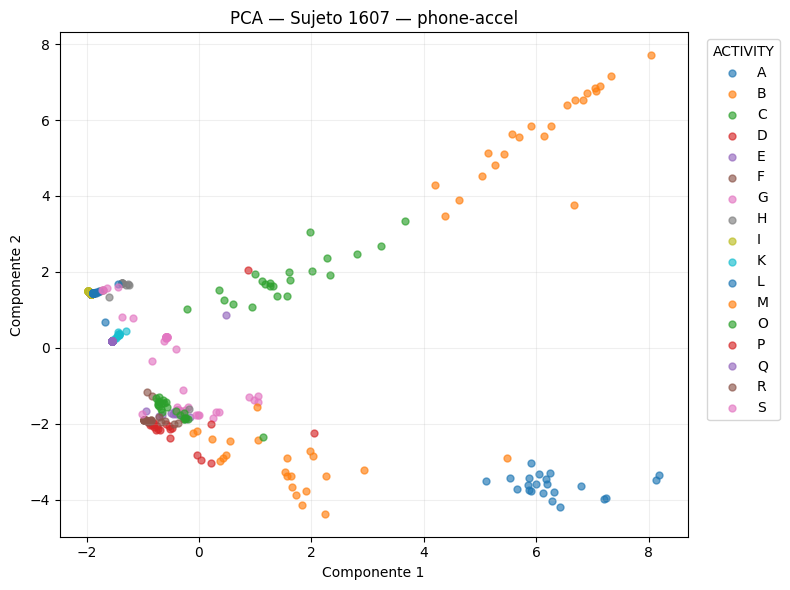

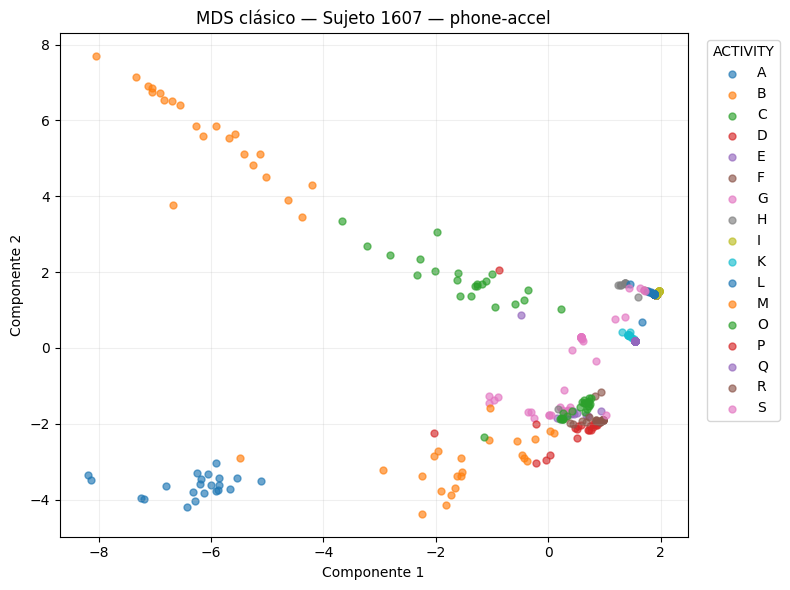

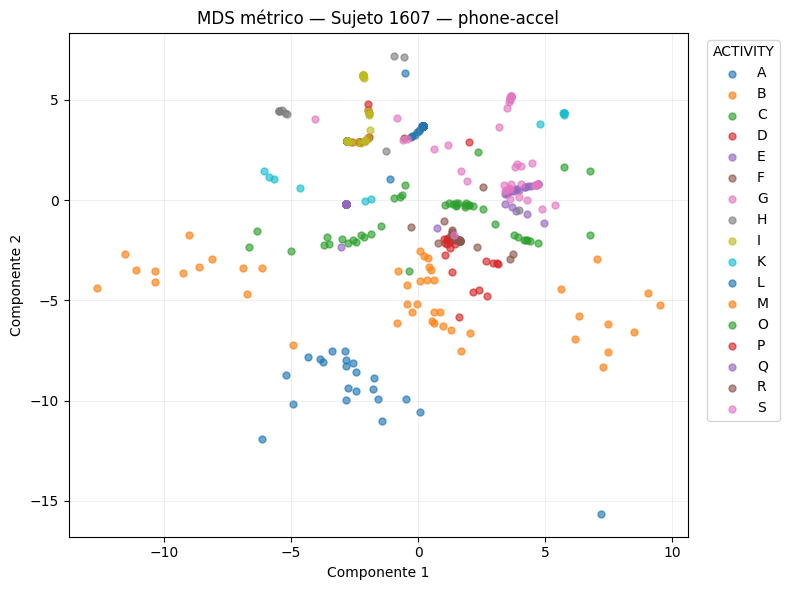

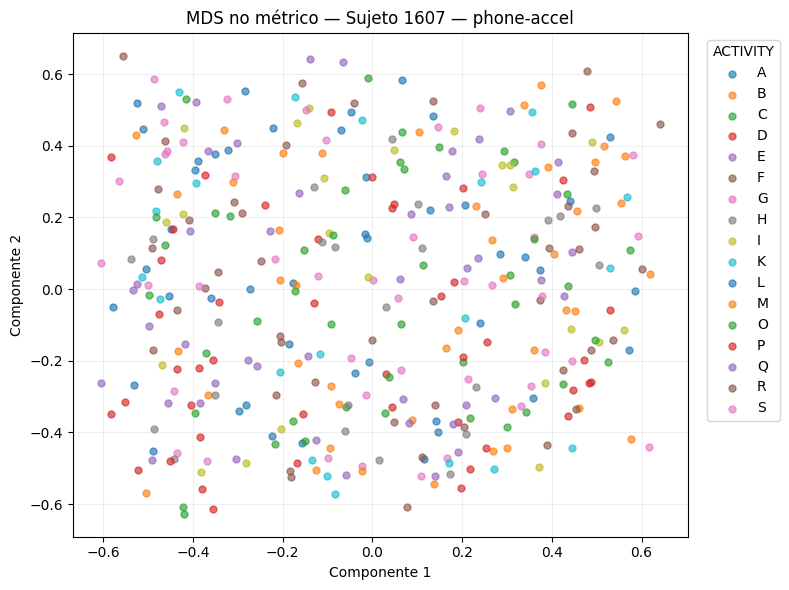

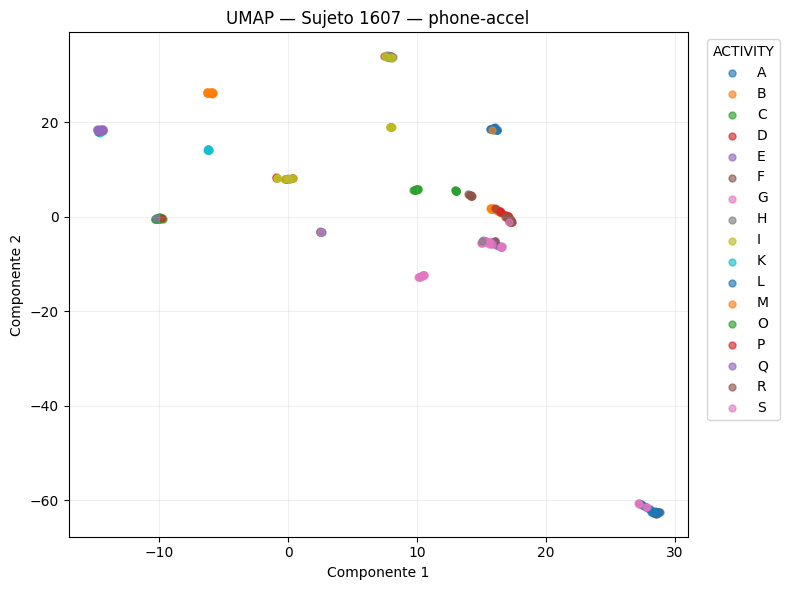


SUJETO 1607 | SENSOR phone-gyro


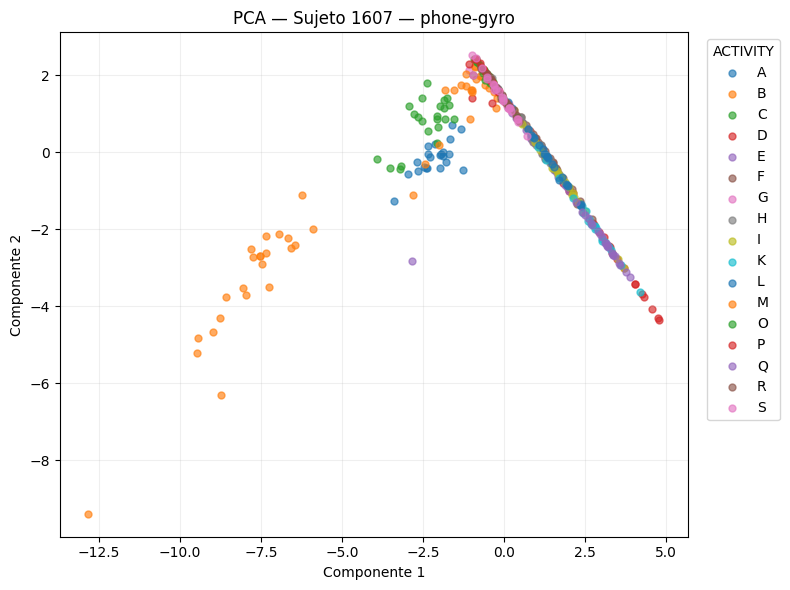

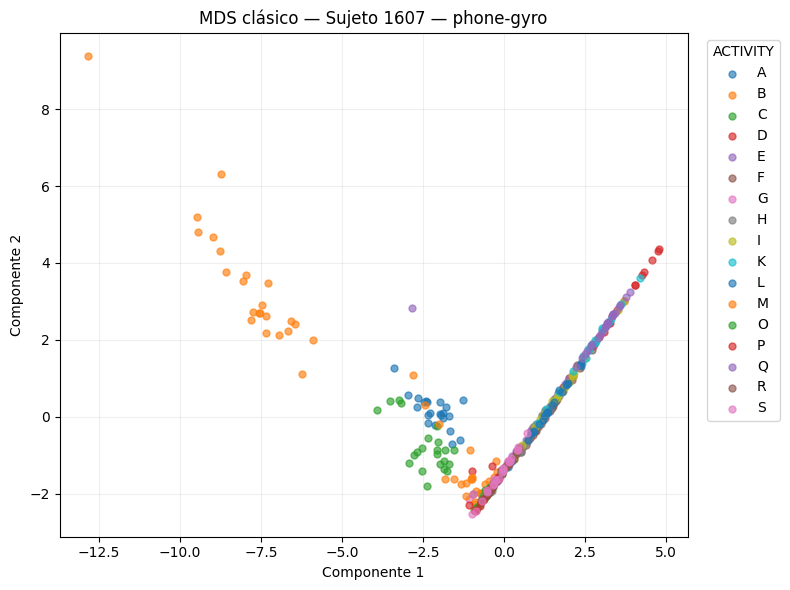

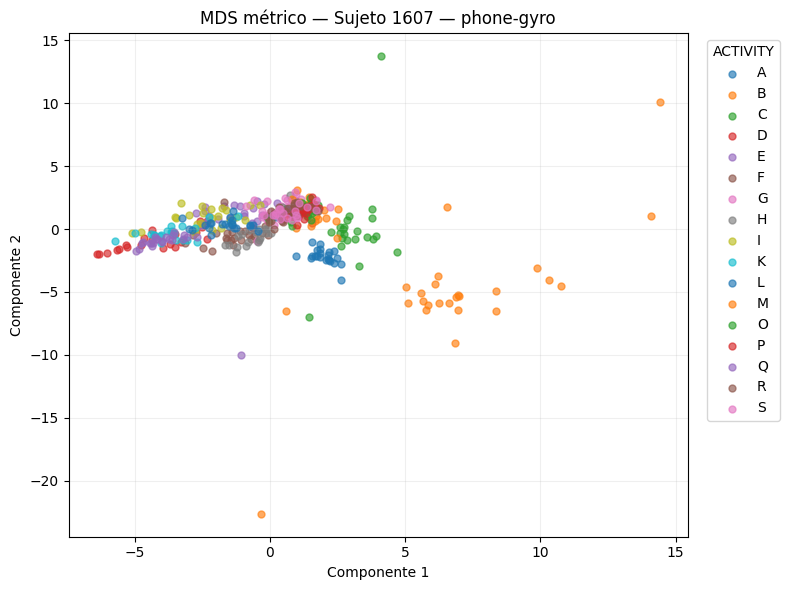

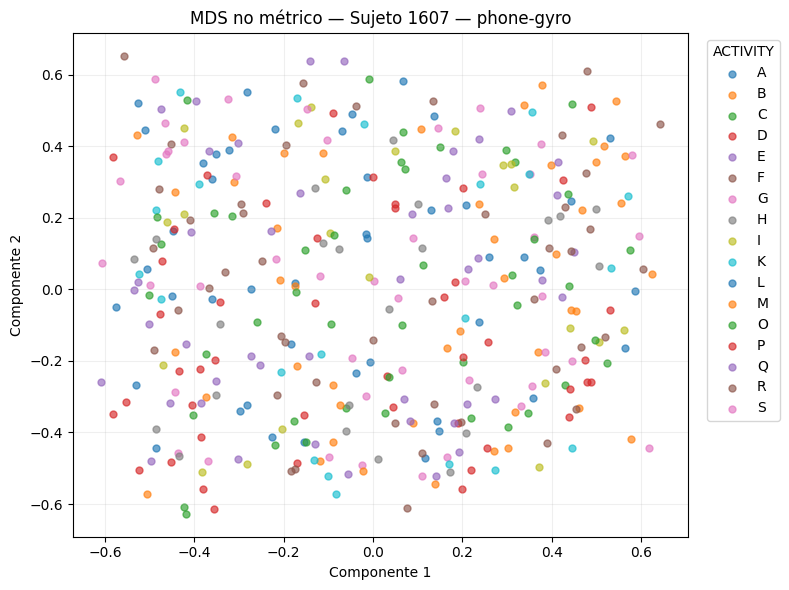

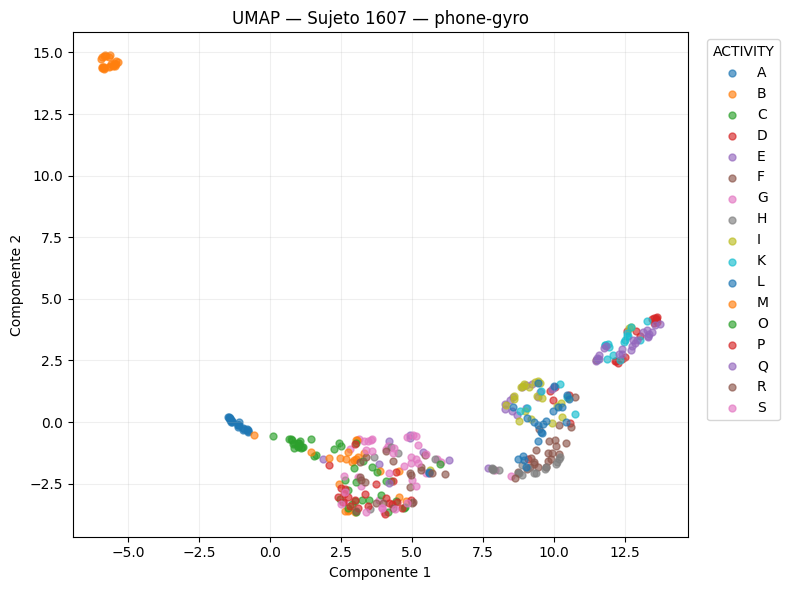


SUJETO 1607 | SENSOR watch-accel


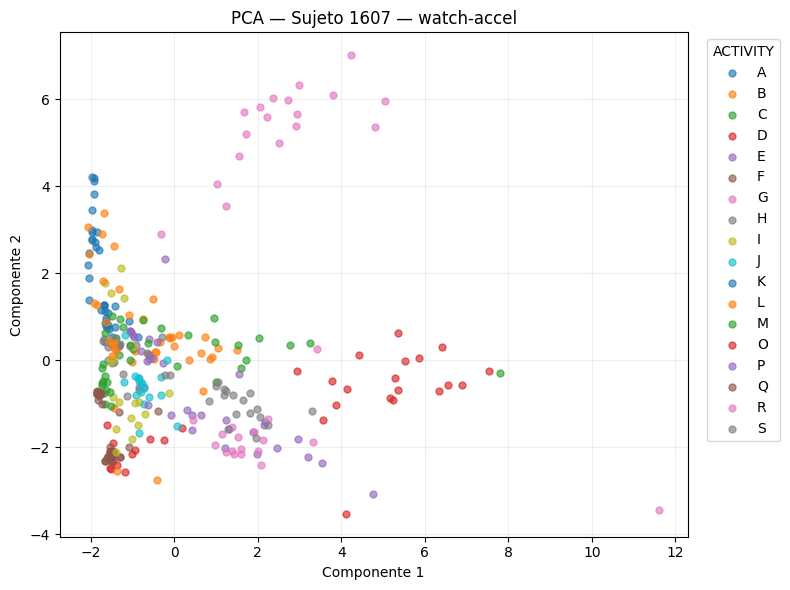

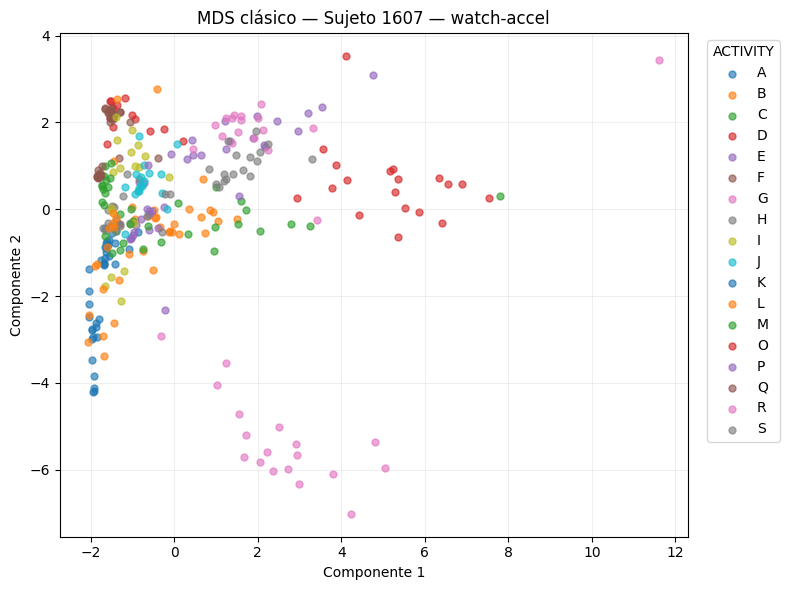

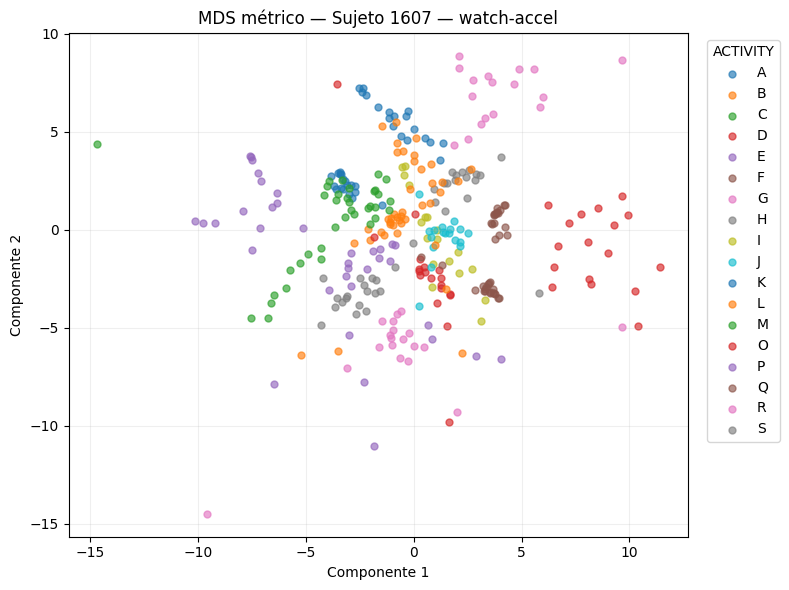

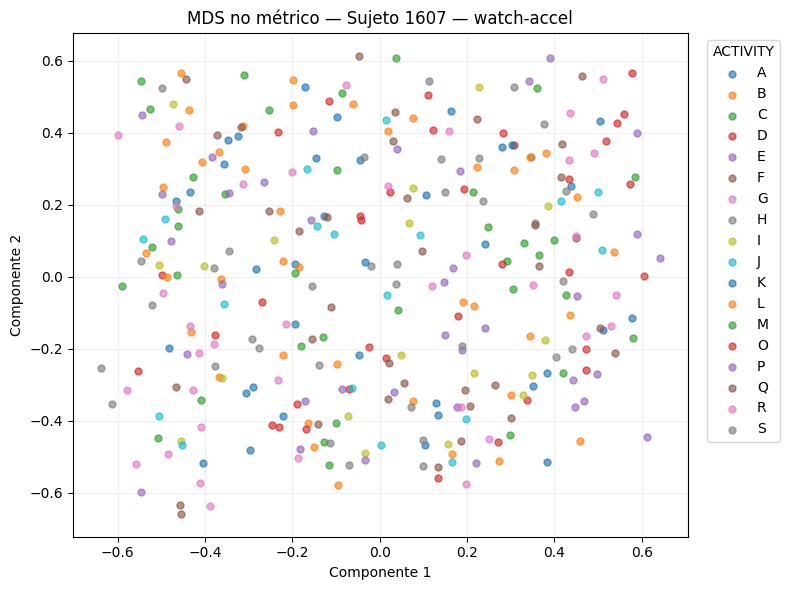

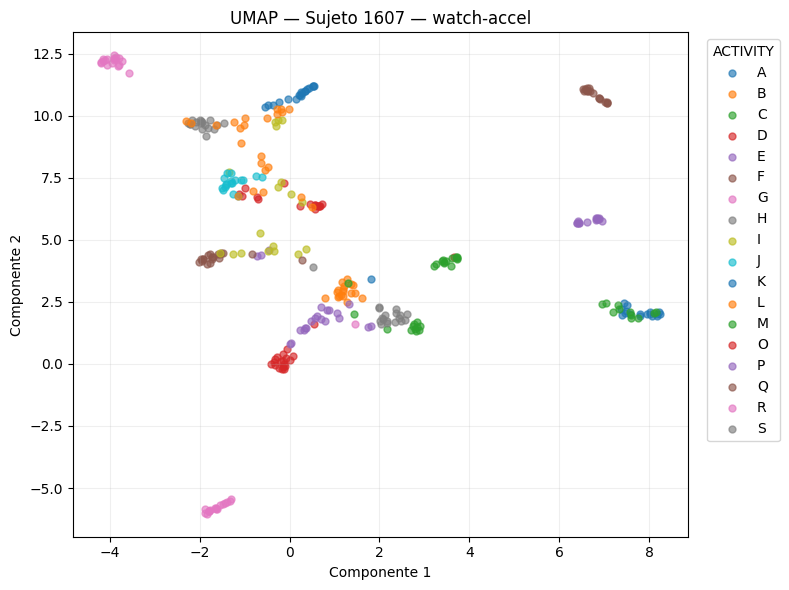


SUJETO 1607 | SENSOR watch-gyro


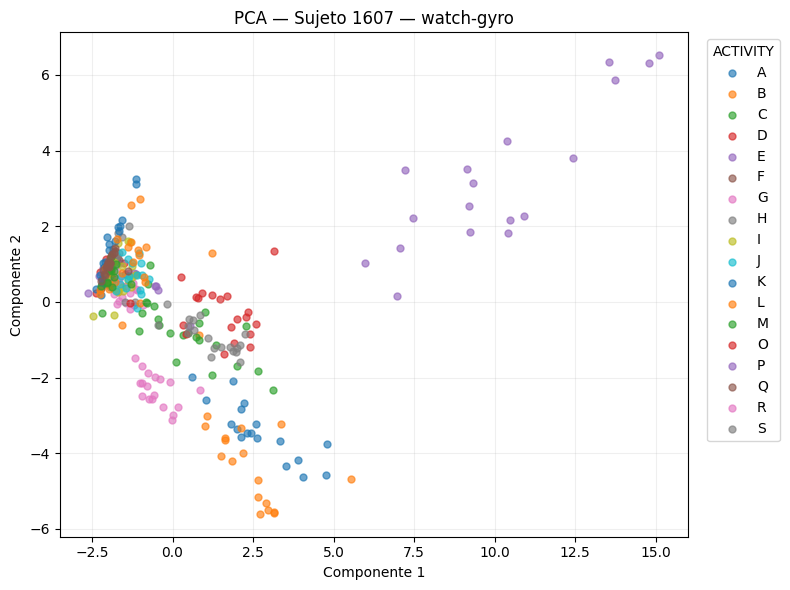

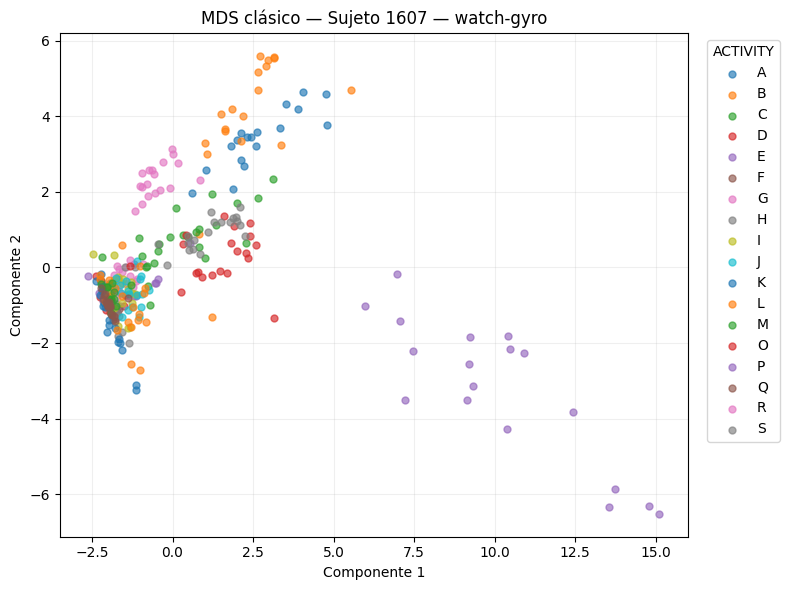

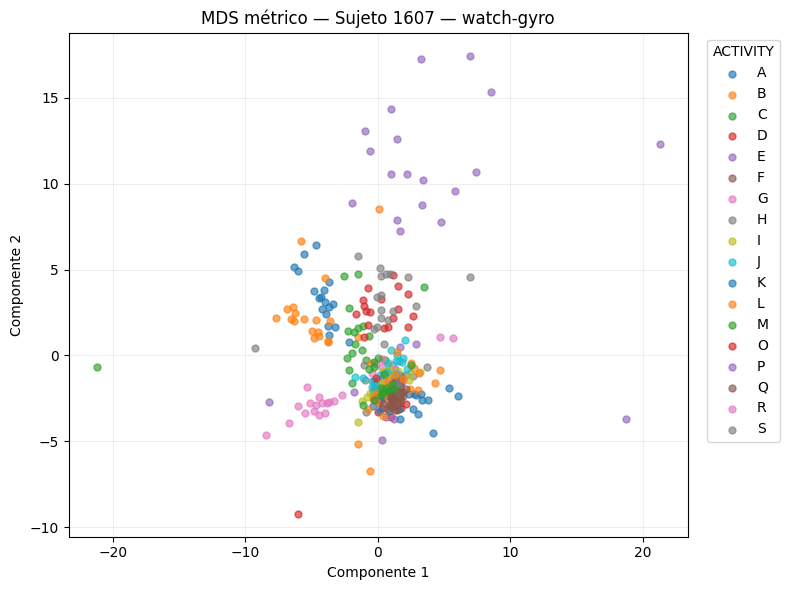

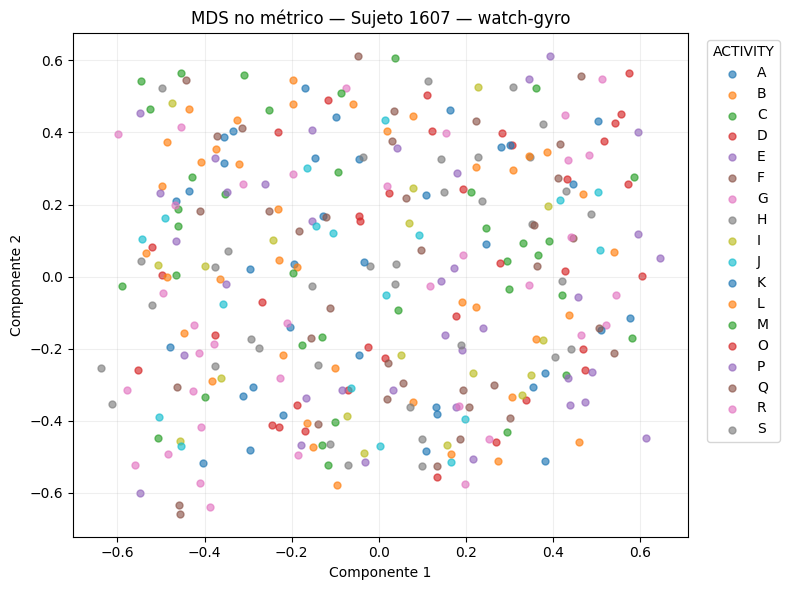

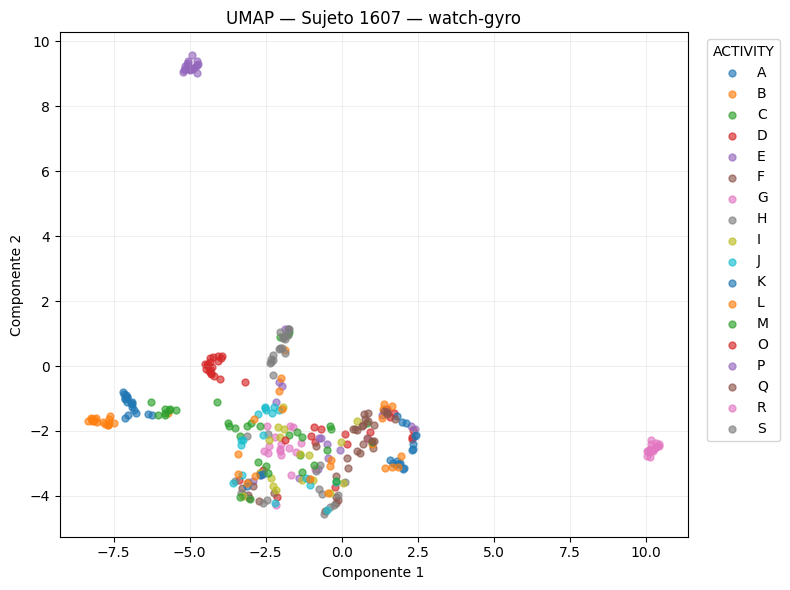


✅ ANÁLISIS INDIVIDUAL TERMINADO — 60 GRÁFICAS


In [70]:
RESULTADOS_INDIVIDUALES = {}

for sujeto in SUJETOS:

    RESULTADOS_INDIVIDUALES[sujeto] = {}

    for sensor in SENSORES:

        print("\n" + "=" * 80)
        print(f"SUJETO {sujeto} | SENSOR {sensor}")
        print("=" * 80)

        X = DATOS[sujeto][sensor]["X"]
        y = DATOS[sujeto][sensor]["y"]

        resultados, etiquetas = ejecutar_metodos(
            X,
            y
        )

        RESULTADOS_INDIVIDUALES[sujeto][sensor] = {
            "resultados": resultados,
            "etiquetas": etiquetas
        }

        for metodo in [
            "PCA",
            "MDS clásico",
            "MDS métrico",
            "MDS no métrico",
            "UMAP"
        ]:

            graficar_resultado(
                resultados[metodo],
                etiquetas[metodo],
                f"{metodo} — Sujeto {sujeto} — {sensor}"
            )

print("\n" + "=" * 80)
print("✅ ANÁLISIS INDIVIDUAL TERMINADO — 60 GRÁFICAS")
print("=" * 80)

Combinación de los tres sujetos



In [71]:
DATOS_COMBINADOS = {}

for sensor in SENSORES:

    X_partes = []
    y_partes = []

    for sujeto in SUJETOS:

        X_partes.append(
            DATOS[sujeto][sensor]["X"]
        )

        y_partes.append(
            DATOS[sujeto][sensor]["y"]
        )

    X_combinado = np.vstack(X_partes)
    y_combinado = np.concatenate(y_partes)

    DATOS_COMBINADOS[sensor] = {
        "X": X_combinado,
        "y": y_combinado
    }

    print(
        f"{sensor:12} | "
        f"X = {X_combinado.shape} | "
        f"actividades = {len(np.unique(y_combinado))}"
    )

print("\n✅ Los cuatro sensores fueron combinados.")

phone-accel  | X = (1507, 30) | actividades = 18
phone-gyro   | X = (1105, 30) | actividades = 18
watch-accel  | X = (991, 30) | actividades = 18
watch-gyro   | X = (991, 30) | actividades = 18

✅ Los cuatro sensores fueron combinados.


#Resultados combinados

Se ejecutan nuevamente los cinco métodos para cada uno de los cuatro sensores combinados.




TRES SUJETOS COMBINADOS | SENSOR phone-accel


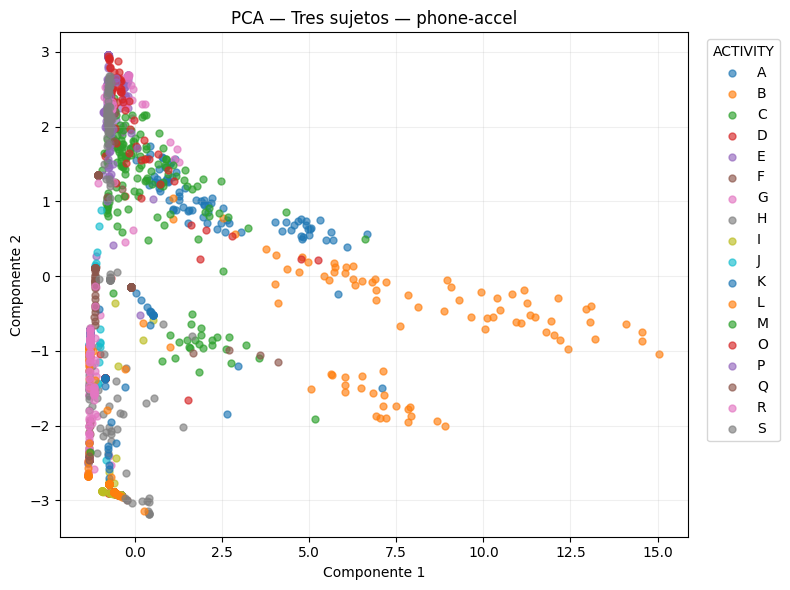

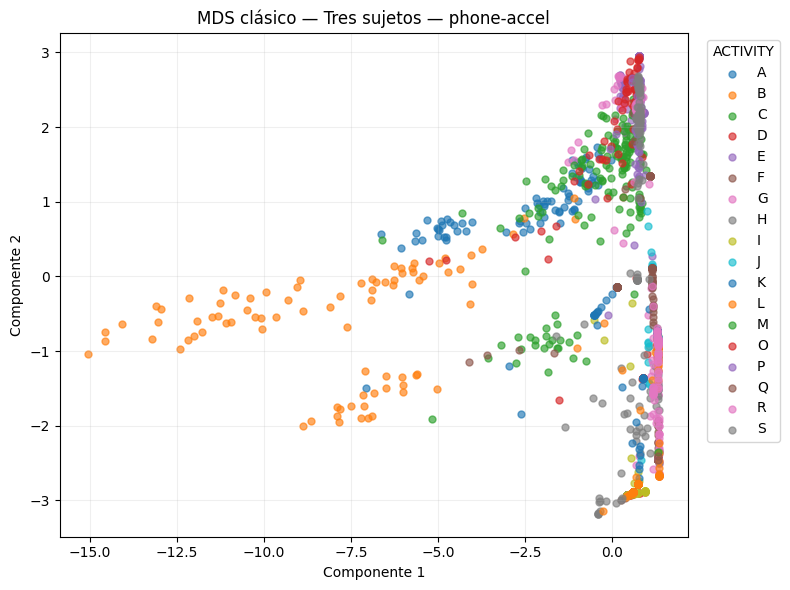

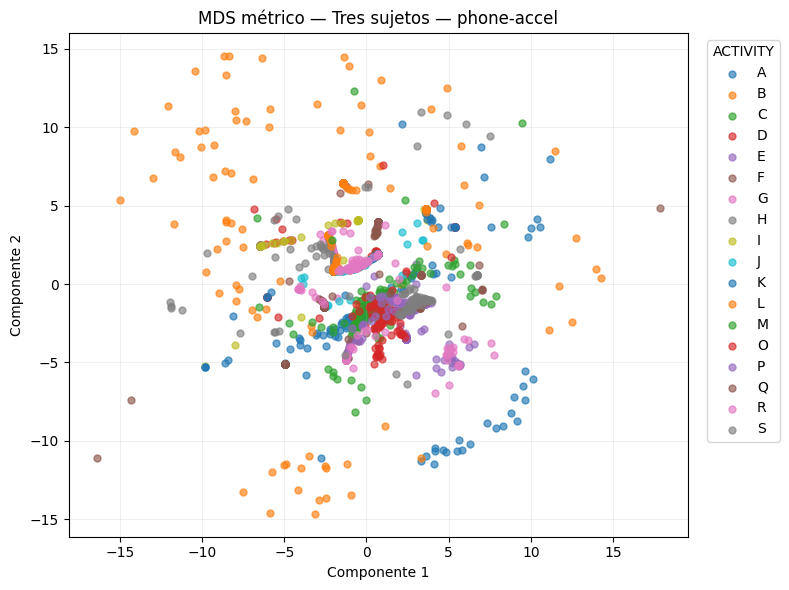

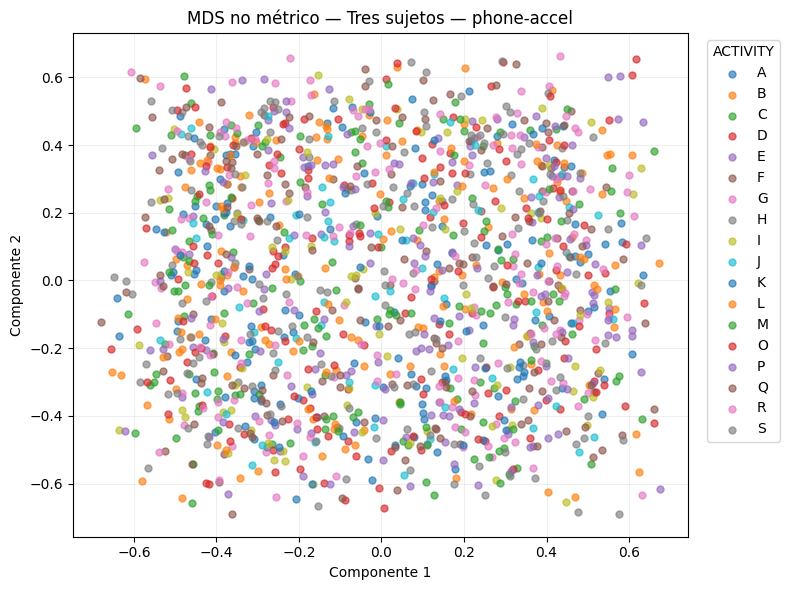

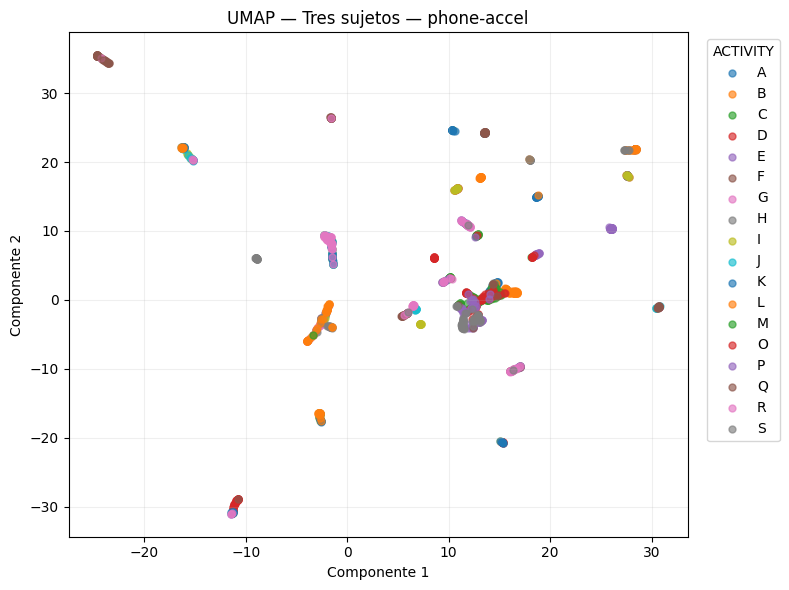


TRES SUJETOS COMBINADOS | SENSOR phone-gyro


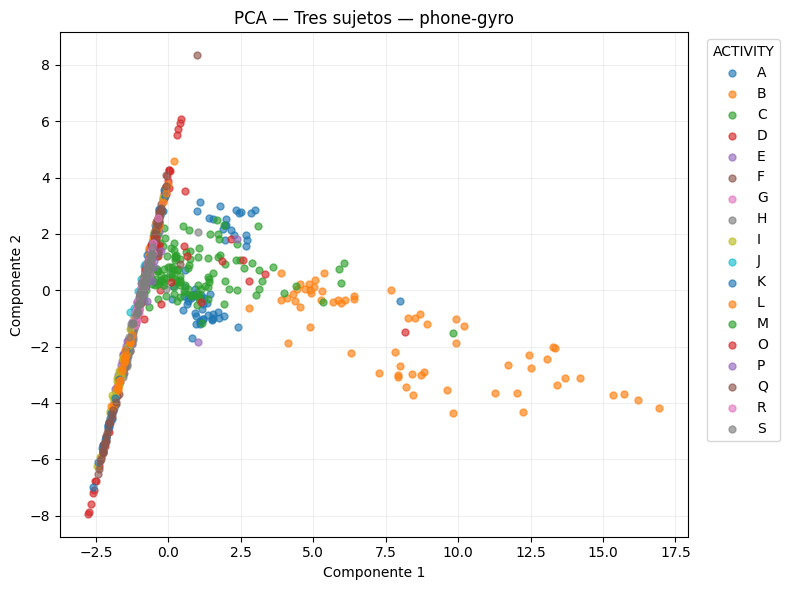

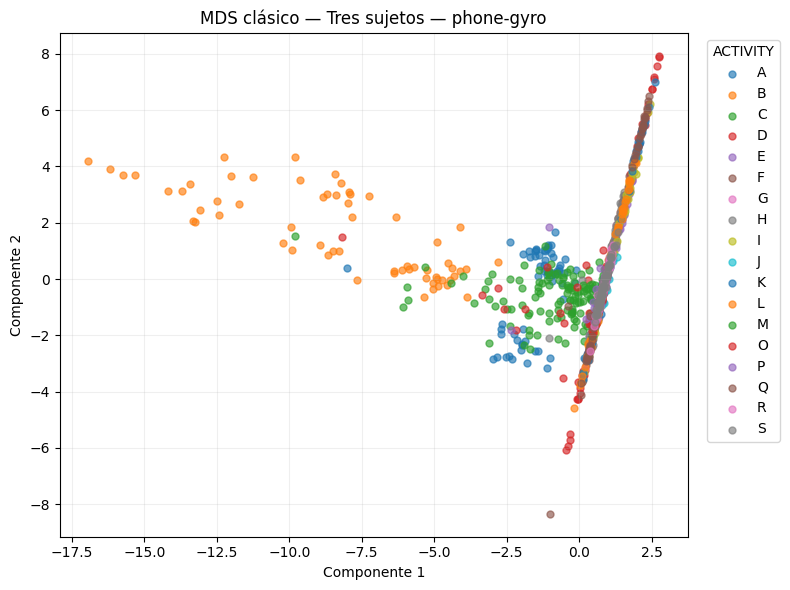

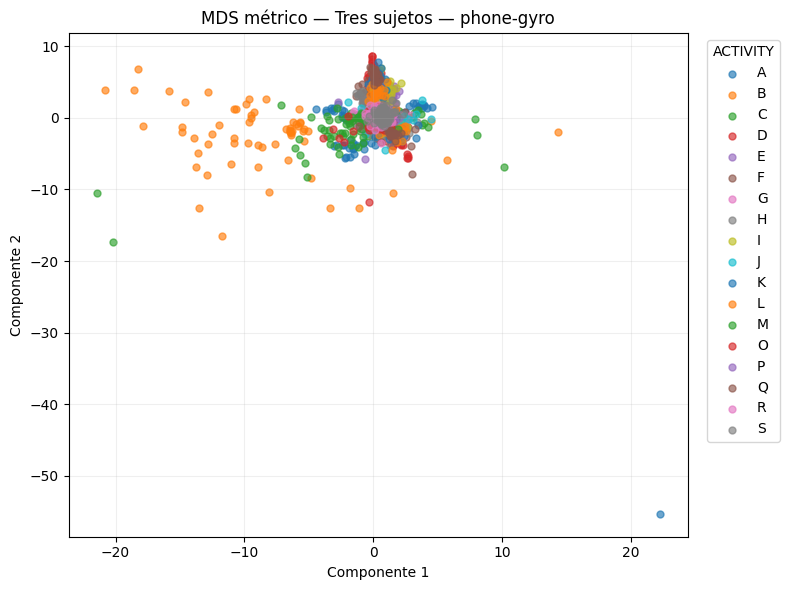

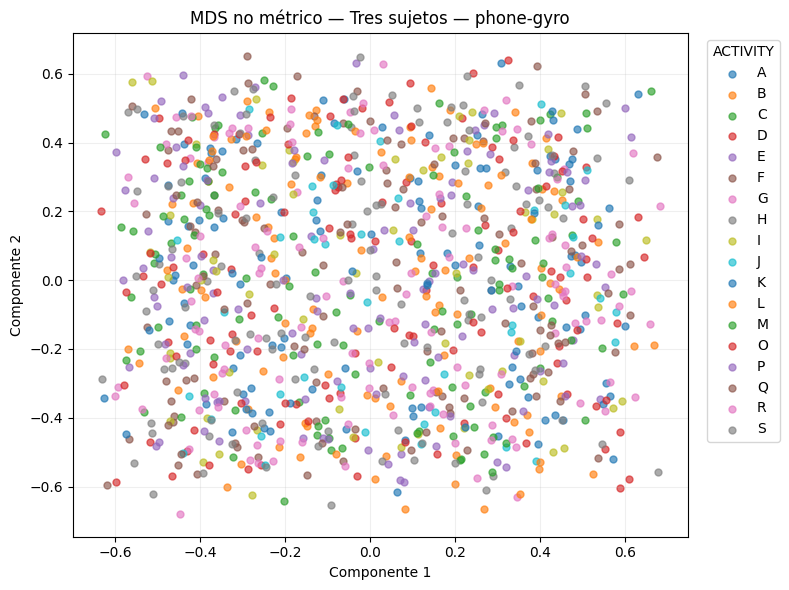

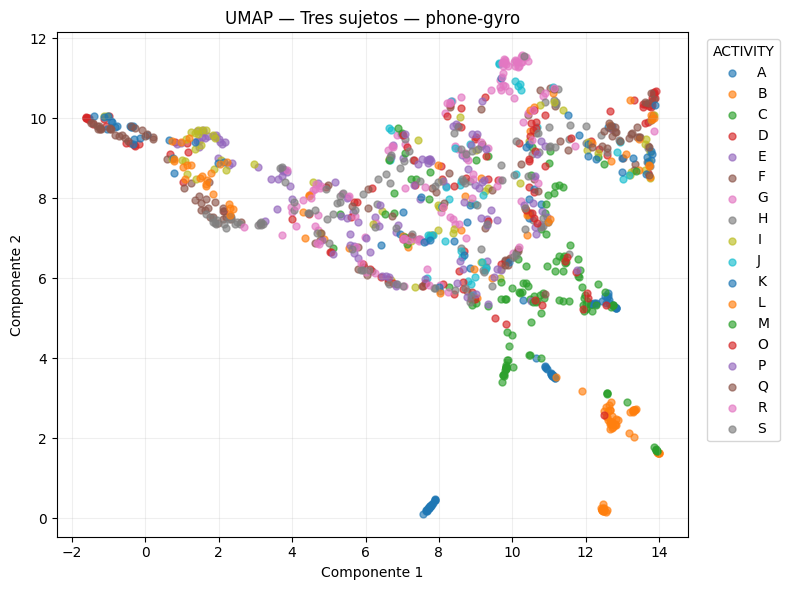


TRES SUJETOS COMBINADOS | SENSOR watch-accel


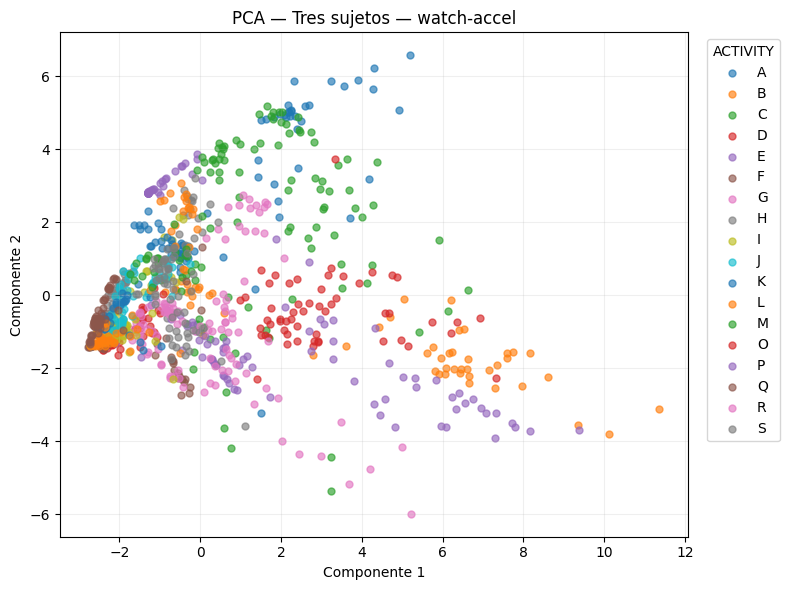

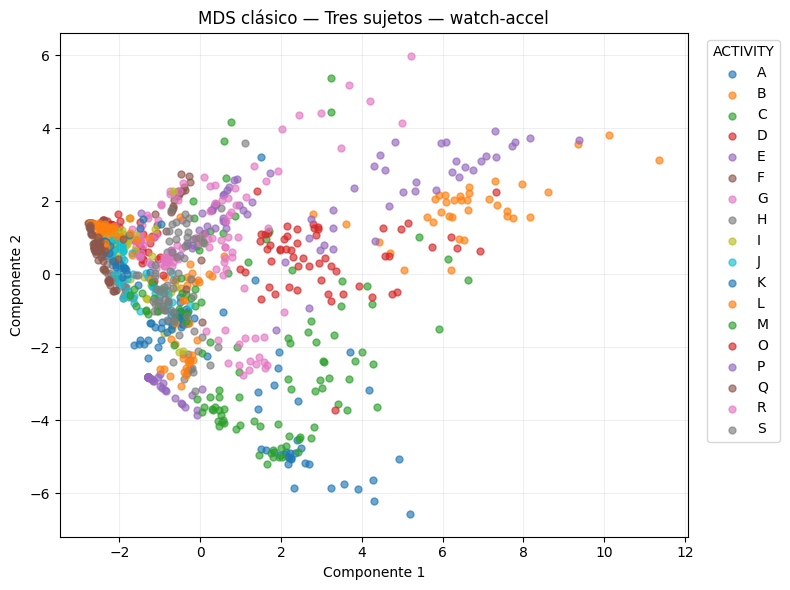

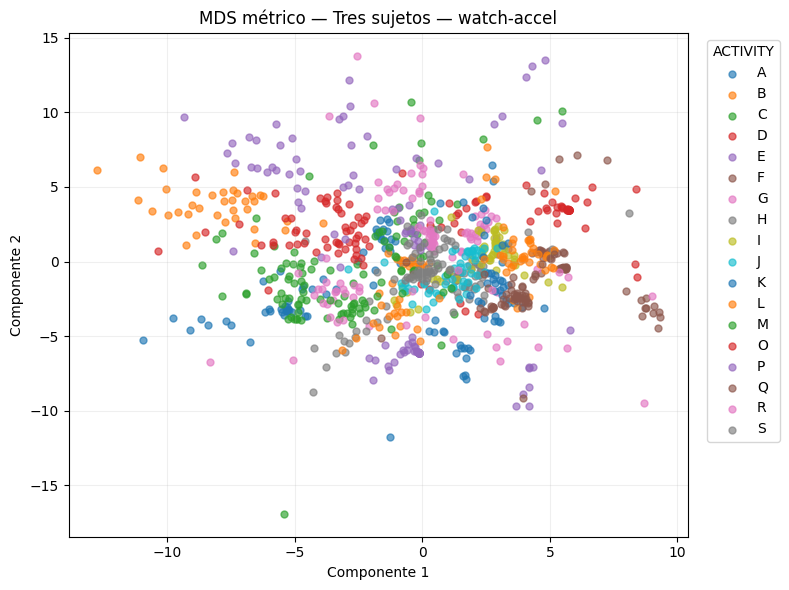

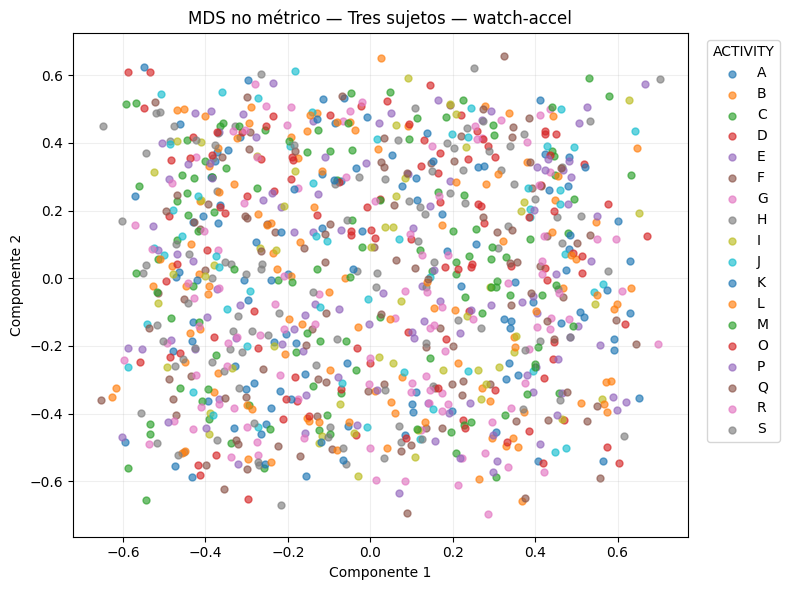

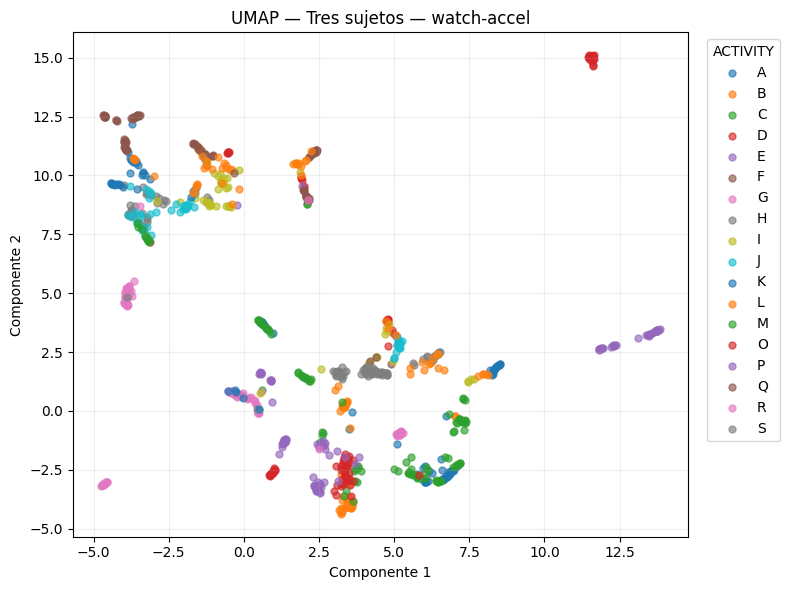


TRES SUJETOS COMBINADOS | SENSOR watch-gyro


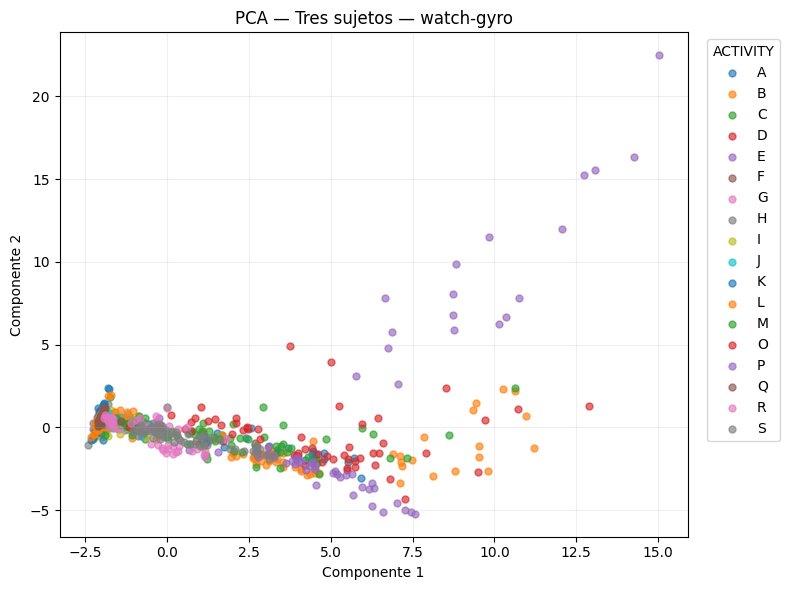

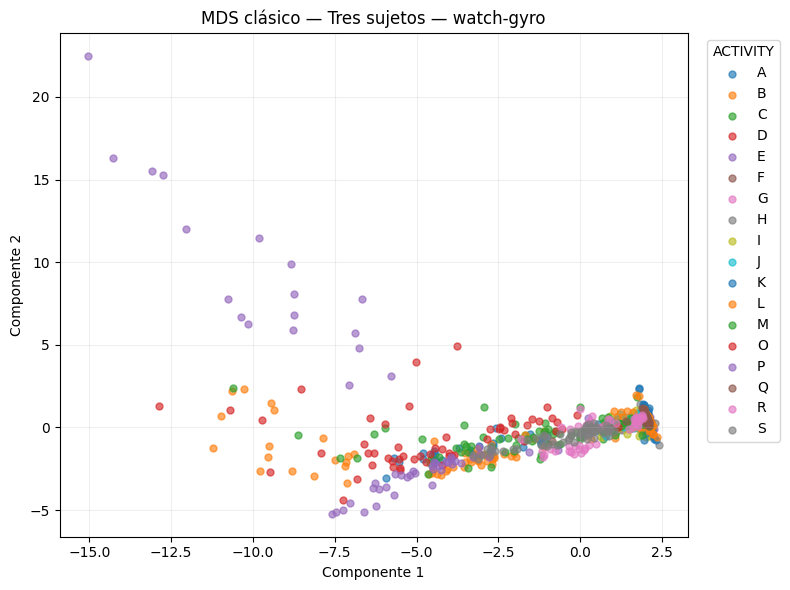

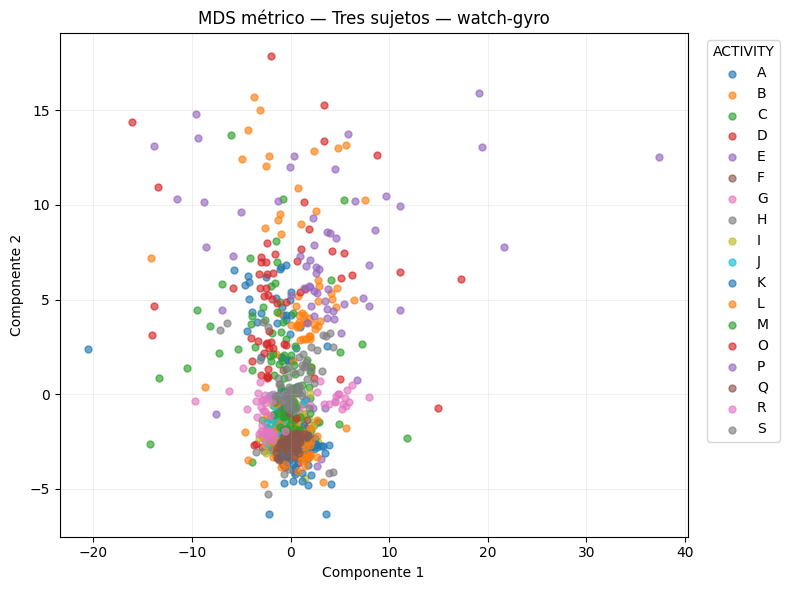

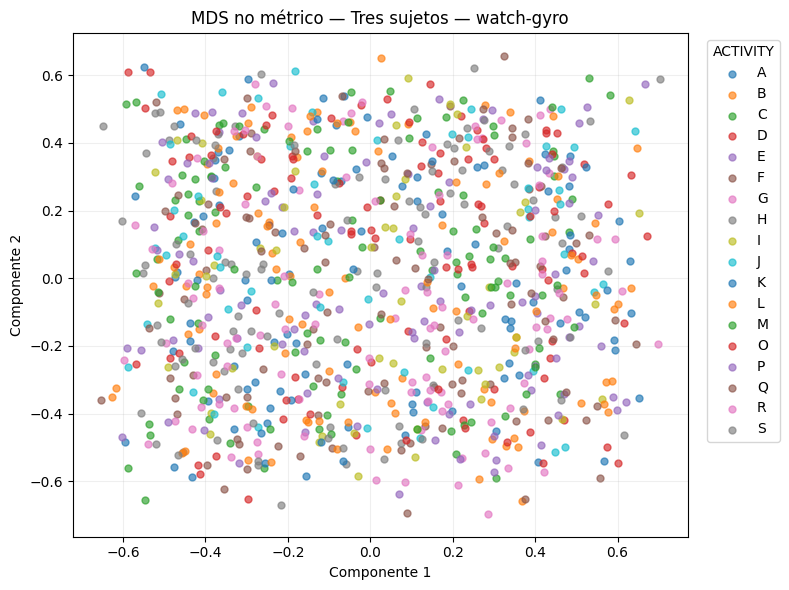

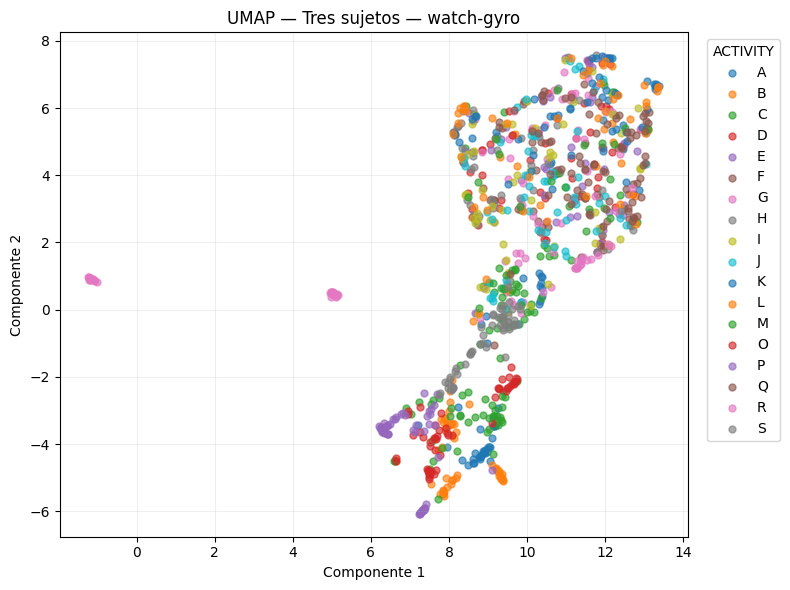


✅ ANÁLISIS COMBINADO TERMINADO — 20 GRÁFICAS


In [72]:
RESULTADOS_COMBINADOS = {}

for sensor in SENSORES:

    print("\n" + "=" * 80)
    print(f"TRES SUJETOS COMBINADOS | SENSOR {sensor}")
    print("=" * 80)

    X = DATOS_COMBINADOS[sensor]["X"]
    y = DATOS_COMBINADOS[sensor]["y"]

    resultados, etiquetas = ejecutar_metodos(
        X,
        y
    )

    RESULTADOS_COMBINADOS[sensor] = {
        "resultados": resultados,
        "etiquetas": etiquetas
    }

    for metodo in [
        "PCA",
        "MDS clásico",
        "MDS métrico",
        "MDS no métrico",
        "UMAP"
    ]:

        graficar_resultado(
            resultados[metodo],
            etiquetas[metodo],
            f"{metodo} — Tres sujetos — {sensor}"
        )

print("\n" + "=" * 80)
print("✅ ANÁLISIS COMBINADO TERMINADO — 20 GRÁFICAS")
print("=" * 80)

#  Evaluación de separación y solapamiento




In [73]:
from sklearn.metrics import silhouette_score, silhouette_samples

def calcular_metricas(resultados, etiquetas):

    filas = []

    for metodo in resultados:

        Z = resultados[metodo]
        y = np.asarray(etiquetas[metodo])


        if len(np.unique(y)) < 2:
            continue

        score_global = silhouette_score(
            Z,
            y
        )

        scores_individuales = silhouette_samples(
            Z,
            y
        )

        actividades = sorted(
            np.unique(y)
        )

        for actividad in actividades:

            mascara = y == actividad

            filas.append({
                "Metodo": metodo,
                "Actividad": actividad,
                "Silhouette actividad":
                    scores_individuales[mascara].mean(),
                "Silhouette global":
                    score_global
            })

    return pd.DataFrame(filas)


METRICAS_INDIVIDUALES = []

for sujeto in SUJETOS:

    for sensor in SENSORES:

        datos_resultado = (
            RESULTADOS_INDIVIDUALES[sujeto][sensor]
        )

        tabla = calcular_metricas(
            datos_resultado["resultados"],
            datos_resultado["etiquetas"]
        )

        tabla.insert(0, "Sujeto", sujeto)
        tabla.insert(1, "Sensor", sensor)

        METRICAS_INDIVIDUALES.append(tabla)


METRICAS_INDIVIDUALES = pd.concat(
    METRICAS_INDIVIDUALES,
    ignore_index=True
)


METRICAS_COMBINADAS = []

for sensor in SENSORES:

    datos_resultado = RESULTADOS_COMBINADOS[sensor]

    tabla = calcular_metricas(
        datos_resultado["resultados"],
        datos_resultado["etiquetas"]
    )

    tabla.insert(0, "Sensor", sensor)

    METRICAS_COMBINADAS.append(tabla)


METRICAS_COMBINADAS = pd.concat(
    METRICAS_COMBINADAS,
    ignore_index=True
)


print("✅ Métricas calculadas.")

✅ Métricas calculadas.


In [74]:
resumen_individual = (
    METRICAS_INDIVIDUALES
    .groupby(["Sujeto", "Sensor", "Metodo"], as_index=False)
    ["Silhouette global"]
    .first()
    .sort_values(
        "Silhouette global",
        ascending=False
    )
)

display(resumen_individual)

print(
    "\nEl mayor silhouette global indica la representación "
    "con mejor separación promedio en 2D para ese conjunto."
)

,Sujeto,Sensor,Metodo,Silhouette global
34,1632,watch-accel,UMAP,0.535752
14,1607,watch-accel,UMAP,0.379660
31,1632,watch-accel,MDS métrico,0.356557
24,1632,phone-accel,UMAP,0.264431
54,1645,watch-accel,UMAP,0.226534
4,1607,phone-accel,UMAP,0.195795
44,1645,phone-accel,UMAP,0.187819
33,1632,watch-accel,PCA,0.180996
30,1632,watch-accel,MDS clásico,0.180996
11,1607,watch-accel,MDS métrico,0.131199



El mayor silhouette global indica la representación con mejor separación promedio en 2D para ese conjunto.


In [75]:
resumen_combinado = (
    METRICAS_COMBINADAS
    .groupby(["Sensor", "Metodo"], as_index=False)
    ["Silhouette global"]
    .first()
    .sort_values(
        "Silhouette global",
        ascending=False
    )
)

display(resumen_combinado)

print(
    "\nEl mayor silhouette global indica la representación "
    "con mejor separación promedio en 2D para ese conjunto."
)

,Sensor,Metodo,Silhouette global
14,watch-accel,UMAP,-0.058633
2,phone-accel,MDS no métrico,-0.099866
7,phone-gyro,MDS no métrico,-0.099902
11,watch-accel,MDS métrico,-0.104094
12,watch-accel,MDS no métrico,-0.107793
17,watch-gyro,MDS no métrico,-0.109753
13,watch-accel,PCA,-0.154946
10,watch-accel,MDS clásico,-0.154946
1,phone-accel,MDS métrico,-0.156426
19,watch-gyro,UMAP,-0.177980



El mayor silhouette global indica la representación con mejor separación promedio en 2D para ese conjunto.


In [76]:
def resumen_actividades(tabla, columnas_grupo):

    salida = []

    for grupo, subtabla in tabla.groupby(columnas_grupo):

        promedio_actividad = (
            subtabla
            .groupby("Actividad")["Silhouette actividad"]
            .mean()
            .sort_values(ascending=False)
        )

        mejor_actividad = promedio_actividad.index[0]
        peor_actividad = promedio_actividad.index[-1]

        salida.append({
            **{
                columna: valor
                for columna, valor in zip(
                    columnas_grupo,
                    grupo if isinstance(grupo, tuple) else [grupo]
                )
            },
            "Mejor separada": mejor_actividad,
            "Silhouette mejor":
                promedio_actividad.iloc[0],
            "Mayor solapamiento": peor_actividad,
            "Silhouette solapamiento":
                promedio_actividad.iloc[-1]
        })

    return pd.DataFrame(salida)


RESUMEN_ACTIVIDADES_INDIVIDUAL = resumen_actividades(
    METRICAS_INDIVIDUALES,
    ["Sujeto", "Sensor"]
)

print("ACTIVIDADES — ANÁLISIS INDIVIDUAL")
display(RESUMEN_ACTIVIDADES_INDIVIDUAL)


RESUMEN_ACTIVIDADES_COMBINADO = resumen_actividades(
    METRICAS_COMBINADAS,
    ["Sensor"]
)

print("\nACTIVIDADES — TRES SUJETOS COMBINADOS")
display(RESUMEN_ACTIVIDADES_COMBINADO)

ACTIVIDADES — ANÁLISIS INDIVIDUAL


,Sujeto,Sensor,Mejor separada,Silhouette mejor,Mayor solapamiento,Silhouette solapamiento
0,1607,phone-accel,A,0.598244,H,-0.373024
1,1607,phone-gyro,B,0.468843,E,-0.355218
2,1607,watch-accel,F,0.541991,L,-0.498493
3,1607,watch-gyro,R,0.475620,E,-0.451340
4,1632,phone-accel,L,0.656835,H,-0.738938
5,1632,phone-gyro,A,0.539776,L,-0.467188
6,1632,watch-accel,E,0.722733,K,-0.452495
7,1632,watch-gyro,B,0.317152,M,-0.400863
8,1645,phone-accel,E,0.638602,L,-0.415062
9,1645,phone-gyro,B,0.416272,O,-0.412368



ACTIVIDADES — TRES SUJETOS COMBINADOS


,Sensor,Mejor separada,Silhouette mejor,Mayor solapamiento,Silhouette solapamiento
0,phone-accel,E,0.310973,G,-0.379370
1,phone-gyro,B,0.253196,I,-0.381707
2,watch-accel,Q,0.296920,L,-0.407031
3,watch-gyro,F,0.119852,M,-0.482672


In [77]:
if resumen_individual.empty or resumen_combinado.empty:
    raise ValueError("No hay métricas disponibles. Ejecuta primero los análisis individual y combinado.")

mejor_individual = resumen_individual.iloc[0]
mejor_combinado = resumen_combinado.iloc[0]

print("=" * 80)
print("RESUMEN FINAL")
print("=" * 80)

print("\nMEJOR REPRESENTACIÓN INDIVIDUAL:")
print(
    f"Sujeto: {mejor_individual['Sujeto']} | "
    f"Sensor: {mejor_individual['Sensor']} | "
    f"Método: {mejor_individual['Metodo']} | "
    f"Silhouette: {mejor_individual['Silhouette global']:.4f}"
)

print("\nMEJOR REPRESENTACIÓN COMBINADA:")
print(
    f"Sensor: {mejor_combinado['Sensor']} | "
    f"Método: {mejor_combinado['Metodo']} | "
    f"Silhouette: {mejor_combinado['Silhouette global']:.4f}"
)

print("\nACTIVIDADES MEJOR SEPARADAS — COMBINADO:")
display(
    RESUMEN_ACTIVIDADES_COMBINADO[
        [
            "Sensor",
            "Mejor separada",
            "Silhouette mejor"
        ]
    ]
)

print("\nACTIVIDADES CON MAYOR SOLAPAMIENTO — COMBINADO:")
display(
    RESUMEN_ACTIVIDADES_COMBINADO[
        [
            "Sensor",
            "Mayor solapamiento",
            "Silhouette solapamiento"
        ]
    ]
)

print("\n✅ Taller completo ejecutado.")
print("Total esperado: 60 gráficas individuales + 20 combinadas = 80 gráficas.")

RESUMEN FINAL

MEJOR REPRESENTACIÓN INDIVIDUAL:
Sujeto: 1632 | Sensor: watch-accel | Método: UMAP | Silhouette: 0.5358

MEJOR REPRESENTACIÓN COMBINADA:
Sensor: watch-accel | Método: UMAP | Silhouette: -0.0586

ACTIVIDADES MEJOR SEPARADAS — COMBINADO:


,Sensor,Mejor separada,Silhouette mejor
0,phone-accel,E,0.310973
1,phone-gyro,B,0.253196
2,watch-accel,Q,0.296920
3,watch-gyro,F,0.119852



ACTIVIDADES CON MAYOR SOLAPAMIENTO — COMBINADO:


,Sensor,Mayor solapamiento,Silhouette solapamiento
0,phone-accel,G,-0.379370
1,phone-gyro,I,-0.381707
2,watch-accel,L,-0.407031
3,watch-gyro,M,-0.482672



✅ Taller completo ejecutado.
Total esperado: 60 gráficas individuales + 20 combinadas = 80 gráficas.


In [79]:


print("=" * 80)
print("RESPUESTAS A LAS PREGUNTAS DEL TALLER")
print("=" * 80)

print("\nColumnas disponibles:")
print(list(RESUMEN_ACTIVIDADES_COMBINADO.columns))


print("\n" + "=" * 80)
print("1. ¿QUÉ ACTIVIDADES SE DIFERENCIAN MEJOR EN DOS DIMENSIONES?")
print("=" * 80)

mejores = (
    RESUMEN_ACTIVIDADES_COMBINADO
    .sort_values(
        "Silhouette mejor",
        ascending=False
    )
    .head(5)
)

columnas_mejores = [
    columna
    for columna in [
        "Sensor",
        "Metodo",
        "Método",
        "Mejor separada",
        "Silhouette mejor"
    ]
    if columna in mejores.columns
]

display(
    mejores[columnas_mejores]
)



print("\n" + "=" * 80)
print("2. ¿QUÉ ACTIVIDADES SE SUPERPONEN EN DOS DIMENSIONES?")
print("=" * 80)

solapadas = (
    RESUMEN_ACTIVIDADES_COMBINADO
    .sort_values(
        "Silhouette solapamiento",
        ascending=True
    )
    .head(5)
)

columnas_solapamiento = [
    columna
    for columna in [
        "Sensor",
        "Metodo",
        "Método",
        "Mayor solapamiento",
        "Silhouette solapamiento"
    ]
    if columna in solapadas.columns
]

display(
    solapadas[columnas_solapamiento]
)


mejor = mejores.iloc[0]
peor = solapadas.iloc[0]

print("\n" + "=" * 80)
print("CONCLUSIÓN")
print("=" * 80)

print(
    f"\nLa actividad que presenta la mejor separación "
    f"según el Silhouette es: "
    f"{mejor['Mejor separada']} "
    f"(Silhouette = {mejor['Silhouette mejor']:.4f})."
)

print(
    f"\nLa actividad que presenta mayor solapamiento "
    f"según el Silhouette es: "
    f"{peor['Mayor solapamiento']} "
    f"(Silhouette = {peor['Silhouette solapamiento']:.4f})."
)

print(
    "\nLos valores de Silhouette más altos representan "
    "una mejor separación entre actividades, mientras "
    "que valores más bajos indican mayor solapamiento."
)

RESPUESTAS A LAS PREGUNTAS DEL TALLER

Columnas disponibles:
['Sensor', 'Mejor separada', 'Silhouette mejor', 'Mayor solapamiento', 'Silhouette solapamiento']

1. ¿QUÉ ACTIVIDADES SE DIFERENCIAN MEJOR EN DOS DIMENSIONES?


,Sensor,Mejor separada,Silhouette mejor
0,phone-accel,E,0.310973
2,watch-accel,Q,0.296920
1,phone-gyro,B,0.253196
3,watch-gyro,F,0.119852



2. ¿QUÉ ACTIVIDADES SE SUPERPONEN EN DOS DIMENSIONES?


,Sensor,Mayor solapamiento,Silhouette solapamiento
3,watch-gyro,M,-0.482672
2,watch-accel,L,-0.407031
1,phone-gyro,I,-0.381707
0,phone-accel,G,-0.379370



CONCLUSIÓN

La actividad que presenta la mejor separación según el Silhouette es: E (Silhouette = 0.3110).

La actividad que presenta mayor solapamiento según el Silhouette es: M (Silhouette = -0.4827).

Los valores de Silhouette más altos representan una mejor separación entre actividades, mientras que valores más bajos indican mayor solapamiento.


# Conclusiones

De acuerdo con las representaciones bidimensionales obtenidas, las
actividades que presentan los valores de Silhouette más altos son las
que muestran una mejor separación respecto a las demás actividades.

Por otro lado, las actividades con valores de Silhouette más bajos
son las que presentan mayor solapamiento en el espacio bidimensional.

Los resultados deben analizarse considerando tanto las gráficas como
los valores de Silhouette, ya que una representación puede mostrar
visualmente agrupamientos que no necesariamente presentan una
separación cuantitativa elevada.